# Семинар 5. Итерационные методы решения СЛАУ (продолжение). МНК

*Внимание! Семинар содержит интерактивные демонстрации. На сайте они представлены в статическом виде. Для работы интерактивных элементов необходимо скачать страницу в формате ipynb и запустить ipynb-файл локально.*

Перед изучением материалов семинара рекомендуем посетить лекцию или посмотреть видеозапись лекции. Ссылки (YouTube): [лекция 4](https://www.youtube.com/live/1MzfHvgqb78?si=bpiHgBxvgt-9TJEO&t=605) (начало темы),  [лекция 5](https://www.youtube.com/live/9yDoZU_WkuQ?si=FucSoS4marfSNVIz&t=73) (продолжение), [лекция 6](https://www.youtube.com/live/BUTUuvs724M?si=Dflbqjl2AdyGauPC&t=3) (ещё одна тема, входящая в семинар). Желательно также предварительно изучить материалы четвёртого семинара.

Предполагается, что читатель знает

* принцип построения метода простых итераций (МПИ),
* критерий сходимости МПИ,
* определение спектрального радиуса матрицы $\rho$ и оценку сверху на $\rho$,
* определение невязки $\textbf{r}^{(s)}$.

# Введение

На прошлом семинаре мы приступили к изучению итерационных методов решения СЛАУ. Напомним, что основная особенность методов этого класса заключается в возможности управлять количеством выполняемых итераций путём изменения требований к точности искомого приближённого решения. В связи с этой особенностью итерационные методы часто оказываются более эффективными, чем прямые методы, и позволяют найти решение СЛАУ большой размерности за разумное время.

Знакомство с итерационными методами мы начали с подробного изучения метода простых итераций (МПИ). Для его построения мы переписали СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ в эквивалентном виде

$$\textbf{x}=(\textbf{E}-\tau\textbf{A})\textbf{x}+\tau\textbf{f}\equiv \textbf{R}\textbf{x}+\textbf{F}.$$

Затем мы расставили индексы итераций и получили формулу для вычисления последовательных приближений к точному решению $\textbf{x}=\textbf{u}$:

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}.$$

Мы видели, что сходимость метода целиком определяется свойствами оператора перехода $\textbf{R}$, которые в данном случае зависят от значения итерационного параметра $\tau$. Напомним, что МПИ сходится тогда и только тогда, когда модули всех собственных значений матрицы $\textbf{R}$ оказываются строго меньше единицы. Это требование ограничивает возможные значения параметра $\tau$. Вид спектра оператора перехода определяет и оптимальное значение параметра $\tau_\text{opt}$, при котором сходимость оказывается наиболее быстрой.

В настоящем семинаре мы продолжим изучение итерационных методов решения СЛАУ и рассмотрим ещё три метода: Якоби, Зейделя и последовательной верхней релаксации (ПВР). Из них первые два являются медленными и редко используются на практике. Третий метод — метод ПВР — имеет среднюю скорость сходимости, и поэтому может применяться для решения реальных задач.

Мы обсудим также принцип релаксации построения итерационных процессов и коснёмся методов вариационного типа.

Предварительно изложим некоторые общие сведения о способах построения и записи итерационных процессов.

# Двухслойные итерационные процессы

Многие итерационные методы решения СЛАУ удаётся построить по аналогии с МПИ. Именно, рассматриваемая СЛАУ каким-либо способом приводится к эквивалентному виду

$$\textbf{x}=\textbf{R}\textbf{x}+\textbf{F}.$$

Затем расставляются индексы итераций и получается итерационный процесс, который внешне тождественен МПИ:

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}.$$

При таком подходе различные методы отличаются лишь способами перехода к эквивалентной СЛАУ, т.е. конкретными выражениями для матрицы $\textbf{R}$ и вектора $\textbf{F}$.

Итерационные процессы, задаваемые последней формулой, принято называть **двухслойными**, поскольку в них каждое следующее приближение $\textbf{x}^{(s+1)}$ зависит только от предыдущего приближения $\textbf{x}^{(s)}$ и не зависит от приближений $\textbf{x}^{(s-1)}$, $\textbf{x}^{(s-2)}$ и т.д. (т.е. в расчёте задействованы лишь два соседних "слоя"). Можно рассматривать и **многослойные** методы решения СЛАУ. Мы не будем на них останавливаться.

Центральным результатом всей теории итерационных методов является следующая теорема, дающая необходимое и достаточное условие сходимости (двухслойного) итерационного процесса.

**Теорема 1 (общий критерий сходимости итерационных методов).** Двухслойный итерационный процесс вида

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}$$

сходится при любом начальном приближении $\textbf{x}^{(0)}$ в том и только в том случае, если спектральный радиус оператора перехода *строго* меньше единицы:

$$\rho(\textbf{R})<1.$$

Иначе говоря, модули **всех** собственных значений матрицы $\textbf{R}$ должны быть строго меньше единицы (т.е. все собственные значения должны лежать в единичном круге на комплексной плоскости). Это требование мы уже встречали при обсуждении сходимости МПИ.

Двухслойные итерационные процессы часто записывают несколько иначе:

$$\textbf{M}\textbf{x}^{(s+1)}=\textbf{N}\textbf{x}^{(s)}+\textbf{f}.$$

На первый взгляд эта запись эквивалентна записи в терминах оператора перехода $\textbf{R}$ (если матрица $\textbf{M}$ обратима) и не вносит ничего нового. Действительно, достаточно положить $\textbf{R}=\textbf{M}^{-1}\textbf{N}$ и $\textbf{F}=\textbf{M}^{-1}\textbf{f}$, чтобы перейти от одного вида метода к другому. Однако при более внимательном рассмотрении различие формул

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}\quad\text{и}\quad\textbf{M}\textbf{x}^{(s+1)}=\textbf{N}\textbf{x}^{(s)}+\textbf{f}$$

оказывается существенным. Запись в терминах матриц $\textbf{M}$ и $\textbf{N}$ более конструктивна и в некоторых источниках принимается за основную.

В самом деле, из этой записи следует, что для построения итерационного метода решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ достаточно представить матрицу $\textbf{A}$ в виде разности $\textbf{M}-\textbf{N}$ так, чтобы матрица $\textbf{M}$ была невырожденной. Такое представление называется **расщеплением** матрицы $\textbf{A}$; матрица $\textbf{M}$ называется **матрицей расщепления**. Конечно, не любое расщепление матрицы СЛАУ может быть положено в основу итерационного процесса. Поскольку $\textbf{R}=\textbf{M}^{-1}\textbf{N}$, сходимость метода будет иметь место лишь при условии $\rho\big(\textbf{M}^{-1}\textbf{N}\big)<1$ (в силу теоремы 1), т.е. матрица расщепления должна выбираться по крайней мере с учётом этого условия. Однако это требование оказывается не единственным.

Из формулы

$$\textbf{M}\textbf{x}^{(s+1)}=\textbf{N}\textbf{x}^{(s)}+\textbf{f}$$

легко понять, как находится новое приближение $\textbf{x}^{(s+1)}$. Если $\textbf{M}=\textbf{E}$, то вектор $\textbf{x}^{(s+1)}$ уже выражен явно, а если $\textbf{M}\neq\textbf{E}$ (и матрица $\textbf{M}$ невырожденна), то вектор $\textbf{x}^{(s+1)}$ задан неявно и **на каждом шаге процесса возникает подзадача — приходится решать СЛАУ с матрицей** $\textbf{M}$. Если выбрать матрицу расщепления $\textbf{M}$ неудачно (например, взять её плотной), то сложность подзадачи окажется сравнимой со сложностью исходной задачи и предложенный итерационный процесс утратит смысл.

Из сказанного следует, что интерес представляют лишь такие итерационные методы, в которых матрица $\textbf{M}$ имеет какую-то специальную структуру, благодаря которой решение СЛАУ с такой матрицей (прямым методом) оказывается менее трудоёмким, чем решение СЛАУ с матрицей $\textbf{A}$. В простейших случаях матрица $\textbf{M}$ берётся диагональной или треугольной (мы увидим это ниже, когда будем строить методы Якоби и Зейделя). Возможны и более сложные варианты. Например, можно построить итерационный процесс, на каждом шаге которого СЛАУ с матрицей расщепления будет решаться методом прогонки (он имеет линейную вычислительную сложность).

Следует помнить, что на практике при организации итерационных процессов, как правило, избегают вычисления обратных матриц. По этой причине формула $\textbf{R}=\textbf{M}^{-1}\textbf{N}$ не должна рассматриваться в качестве расчётной. Если оператор перехода некоторого метода записан в таком виде, то можно утверждать, что на каждом шаге процесса требуется решать СЛАУ с матрицей $\textbf{M}$. В отдельных случаях это можно сделать аналитически, и тогда удаётся получить расчётные формулы метода.

Более подробно о решениях СЛАУ методами, использующими идею расщепления, мы поговорим в весеннем семестре, когда будем обсуждать численное решение дифференциальных уравнений в частных производных эллиптического типа.

# Методы Якоби и Зейделя

Итак, при построении итерационных методов решения СЛАУ на основе идеи расщепления стараются так подбирать матрицу $\textbf{M}$, чтобы СЛАУ с этой матрицей сравнительно легко решалась некоторым прямым методом. Среди всех прямых методов ведущую роль играет, как известно, метод Гаусса. Очевидно, что он особенно просто формулируется в двух случаях: когда матрица решаемой системы диагональна и когда она имеет треугольный вид (для определённости — нижнетреугольный). Выбрав соответствующие матрицы расщепления $\textbf{M}$, мы получим два итерационных метода. Первый из них называется **методом Якоби**, второй — **методом Зейделя** (иногда Гаусса—Зейделя).

Для удобства представим матрицу СЛАУ $\textbf{A}$ как **сумму** трёх матриц:

$$\textbf{A}=\textbf{L}+\textbf{D}+\textbf{U},$$

где $\textbf{D}=\text{diag}(d_i)$ — диагональная матрица, а $\textbf{L}=(l_{ij})$ и $\textbf{U}=(u_{ij})$ — соответственно нижнетреугольная и верхнетреугольная матрицы с нулями на главой диагонали. **Не следует путать указанное представление матрицы $\textbf{A}$ с её $\textbf{LU}$-разложением (имеющим вид $\textbf{A}=\textbf{L}\textbf{U}$)!**

Чтобы построить метод Якоби, выбираем матрицу расщепления $\textbf{M}=\textbf{D}$. Тогда $\textbf{N}=-\textbf{L}-\textbf{U}$. Итерационный процесс приобретает вид:

$$\textbf{D}\textbf{x}^{(s+1)}=-\textbf{L}\textbf{x}^{(s)}-\textbf{U}\textbf{x}^{(s)}+\textbf{f}.$$

Переходя к покомпонентной записи (для $i$-го уравнения), получаем:

$$d_ix_i^{(s+1)}=-\sum\limits_{j=1}^n l_{ij}x_j^{(s)}-\sum\limits_{j=1}^n u_{ij}x_j^{(s)}+f_i,\quad i=1,\,2,\,\dots,\, n.$$

Как видим, компоненты $(s+1)$-го приближения действительно очень легко выражаются явно — за счёт диагональной структуры матрицы расщепления (предполагается, что все $d_i$ отличны от нуля):

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^n l_{ij}x_j^{(s)}-\sum\limits_{j=1}^n u_{ij}x_j^{(s)}\bigg)\Big/d_i,\quad i=1,\,2,\,\dots,\, n.$$

Остаётся только заметить, что

$$d_i=a_{ii};\qquad l_{ij}=
  \begin{cases}
    a_{ij}, &i> j,\\
    0, &i\leq j;
  \end{cases}
  \qquad u_{ij}=
  \begin{cases}
    0, &i\geq j,\\
    a_{ij}, &i< j.
  \end{cases}$$

Поэтому

$$\sum\limits_{j=1}^n l_{ij}x_j^{(s)}=\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s)},\quad \sum\limits_{j=1}^n u_{ij}x_j^{(s)}=\sum\limits_{j=i+1}^{n} a_{ij}x_j^{(s)}.$$

Напомним, что если верхний предел суммы меньше нижнего, то сумма считается равной нулю. Окончательно:

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s)}-\sum\limits_{j=i+1}^{n} a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\, n.$$

Эта формула даёт покомпонентную запись метода Якоби и является основной расчётной формулой, используемой при его программных реализациях. Подчеркнём, что **порядок вычисления компонент** на текущей итерации метода Якоби **может быть любым** ($n$ значений индекса $i$ могут идти в любой последовательности).

Похожим образом строится метод Зейделя. В этом случае за матрицу расщепления принимается нижнетреугольная матрица (в которую входят и диагональные элементы матрицы $\textbf{A}$), т.е. $\textbf{M}=\textbf{L}+\textbf{D}$, а $\textbf{N}=-\textbf{U}$. В векторно-матричной форме метод записывается так:

$$(\textbf{L}+\textbf{D})\textbf{x}^{(s+1)}=-\textbf{U}\textbf{x}^{(s)}+\textbf{f}.$$

Рассуждая так же, как и выше, можно прийти к покомпонентной записи метода Зейделя:

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^{n} a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\, n.$$

Эта формула отличается от формулы метода Якоби расстановкой индексов итераций: неизвестные из первой суммы имеют индекс $s+1$, а не индекс $s$. Таким образом, явное выражение для компонент приближённого решения $x_i^{(s+1)}$ не получается так же просто, как в методе Якоби. С практической точки зрения это означает, что **в методе Зейделя порядок вычисления компонент строго фиксирован**: их нужно находить от первой к последней (значения индекса $i$ должны последовательно увеличиваться, иначе невозможно будет найти первую сумму из правой части).

Разумеется, и метод Якоби, и метод Зейделя можно было бы получить и без использования понятия матрицы расщепления. В самом деле, ведь для подготовки СЛАУ к выполнению итераций достаточно как-либо уединить вектор неизвестных $\textbf{x}$ в левой части. Простой способ сделать это подсказывается покомпонентной формой СЛАУ, в которой $i$-е уравнение выглядит так:

$$\sum\limits_{j=1}^na_{ij}x_j=f_i,\quad i=1,\,2,\,\dots,\,n.$$

Очевидно, что можно выписать отдельно $i$-е слагаемое суммы:

$$\sum\limits_{j=1}^{i-1}a_{ij}x_j+a_{ii}x_i+\sum\limits_{j=i+1}^{n}a_{ij}x_j=f_i,\quad i=1,\,2,\,\dots,\,n,$$

а затем выразить компоненту $x_i$ (в предположении, что $a_{ii}\neq 0$):

$$x_i=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j-\sum\limits_{j=i+1}^n a_{ij}x_j\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\,n.$$

С помощью полученного равенства уже можно строить итерационные процессы — для этого нужно расставить индексы итераций. Естественно сделать это так же, как и в МПИ: справа поставить индекс текущей итерации ($s$), слева — индекс следующей итерации ($s+1$):

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\,n.$$

Мы получили уже известную нам формулу метода Якоби с произвольным порядком подсчёта компонент решения.

Далее можно условиться вычислять компоненты решения в строго определённом порядке. Естественно выбрать порядок, при котором индекс $i$ последовательно пробегает значения от $1$ до $n$. Тогда при расчёте, например, компоненты $x_3^{(s+1)}$ уже будут известны компоненты $x_1^{(s+1)}$ и $x_2^{(s+1)}$, так что их можно будет вставить в первую сумму вместо компонент $x_1^{(s)}$ и $x_2^{(s)}$. Иначе говоря, благодаря фиксированному порядку значений индекса $i$ можно заменить индекс итераций $s$ в первой сумме на индекс $s+1$ и прийти к формуле метода Зейделя:

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\,n.$$

Выше мы специально разобрали способы построения методов Якоби и Зейделя в векторно-матричном виде, чтобы показать на их примере, по какому принципу получаются все основные итерационные методы решения СЛАУ. Повторим, что ключевая идея здесь — так построить расщепление $\textbf{A}=\textbf{M}-\textbf{N}$, чтобы СЛАУ с матрицей $\textbf{M}$ решалась легче, чем СЛАУ с матрицей $\textbf{A}$.

Векторно-матричные формулы, благодаря своей компактности, удобны для теоретического анализа итерационных методов. На практике же используются покомпонентные формулы; расчёт по ним обычно осуществляют в циклах. Для ускорения циклов (и вообще для повышения эффективности программ, реализующих численные методы) часто прибегают к **параллельным вычислениям**.

Из сказанного выше следует, что параллельные расчёты можно легко организовать в случае метода Якоби, поскольку в нём разные компоненты нового приближения к решению СЛАУ не зависят друг от друга (в отличие от метода Зейделя). При большом числе параллельных потоков эффективность метода Якоби может увеличиться настолько, что он из медленного (при последовательных расчётах) метода превратится в достаточно эффективный метод, представляющий практический интерес.

Приведённый пример показывает, что **не следует категорично подразделять численные методы на старые** (ненужные, бесполезные) **и новые** (полезные). Иногда бывает так, что усовершенствование вычислительной техники или какое-либо другое продвижение в науке открывает новые перспективы для использования уже известных методов. Подобные примеры можно найти не только среди методов решения СЛАУ, но и среди разностных схем для уравнений в частных производных. Это — ещё одна причина изучать классические методы (и вообще вычислительную математику): в любой момент может возникнуть потребность пересмотреть элементарные основы предмета для того, чтобы в конце концов прийти к чему-то новому.

Написание программ для методов Якоби и Зейделя мы оставляем читателю (см. практическую задачу A).

## Каноническая форма двухслойных итерационных процессов

Иногда итерационные процессы вида

$$\textbf{M}\textbf{x}^{(s+1)}=\textbf{N}\textbf{x}^{(s)}+\textbf{f}$$

записывают по-другому. Так как $\textbf{A}=\textbf{M}-\textbf{N}$, то $\textbf{N}=\textbf{M}-\textbf{A}$, т.е.

$$\textbf{M}(\textbf{x}^{(s+1)}-\textbf{x}^{(s)})+\textbf{A}\textbf{x}^{(s)}=\textbf{f}.$$

Положим $\textbf{B}=\tau\textbf{M}$, где $\tau$ — некоторое число (итерационный параметр). Тогда

$$\textbf{B}\,\frac{\textbf{x}^{(s+1)}-\textbf{x}^{(s)}}{\tau}+\textbf{A}\textbf{x}^{(s)}=\textbf{f}.$$

Можно обобщить этот итерационный метод, снабдив параметр $\tau$ индексом $s$, т.е. допустив использование не одного параметра, а последовательности из параметров:

$$\textbf{B}\,\frac{\textbf{x}^{(s+1)}-\textbf{x}^{(s)}}{\tau_s}+\textbf{A}\textbf{x}^{(s)}=\textbf{f}.$$

Мы пришли к так называемой **канонической форме двухслойных итерационных процессов**. Нетрудно заметить, что эта формула охватывает все рассмотренные ранее итерационные методы:

* при $\textbf{B}=\textbf{E}$, $\tau_s=\tau$ для всех $s$ получаем (однопараметрический) МПИ,

* при $\textbf{B}=\textbf{E}$, $\tau_s=\tau_k$, где $k=(s\text{ mod } m)+1$, получаем $m$-шаговый МПИ (символ $\text{mod}$ означает операцию взятия остатка от деления целых чисел),

* при $\textbf{B}=\textbf{D}$, $\tau_s=1$ для всех $s$ получаем метод Якоби,

* при $\textbf{B}=\textbf{L}+\textbf{D}$, $\tau_s=1$ для всех $s$ получаем метод Зейделя.

Процессы с $\textbf{B}=\textbf{E}$ называются **явными**, а с $\textbf{B}\neq\textbf{E}$ — **неявными**. После сказанного выше смысл этих названий очевиден: во втором случае, в отличие от первого, для нахождения вектора $\textbf{x}^{(s+1)}$ на каждой итерации приходится решать СЛАУ.

Заметим, что отношение $(\textbf{x}^{(s+1)}-\textbf{x}^{(s)})/\tau_s$ из левой части канонической формы двухслойных процессов можно интерпретировать как конечно-разностную аппроксимацию производной $\dot{\textbf{x}}(t)$. Если решение, как принято говорить, "**вышло на стационар**", то $\dot{\textbf{x}}(t)=0$ и верно $\textbf{A}\textbf{x}=\textbf{f}$. Таким образом, искусственное введение в стационарную задачу производной по времени даёт не только формулу для расчёта новых приближений, но и критерий остановки итераций — малость разности $\textbf{x}^{(s+1)}-\textbf{x}^{(s)}$ (в данном случае — в смысле нормы). С подобным приёмом мы ещё столкнёмся в весеннем семестре.

Надо сказать, что в ряде книг двухслойные итерационные процессы записываются так:

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\textbf{C}^{(s)}\big(\textbf{f}-\textbf{A}\textbf{x}^{(s)}\big)\equiv \textbf{x}^{(s)}+\textbf{C}^{(s)}\textbf{r}^{(s)}.$$

Здесь $\textbf{C}^{(s)}$ — некоторая последовательность невырожденных матриц. Очевидно, что внешне эта форма итерационных методов мало чем отличается от канонической (отличие сводится к переобозначению $\textbf{C}^{(s)}=\tau_s\textbf{B}^{-1}$), хотя и оказывается более общей (матрицы $\textbf{C}^{(s)}$ могут меняться как угодно, а не только за счёт умножения заданной матрицы $\textbf{B}$ на разные параметры $\tau_s$). Дополнительно заметим, что если $\textbf{C}^{(s)}=\textbf{C}$ для всех $s$, то процесс называется **стационарным**, в противном случае — **нестационарным**.

Отметим, что все рассмотренные до сих пор итерационные методы были **линейными**, т.е. так или иначе сводились к последовательному действию на приближения $\textbf{x}^{(s)}$ некоторым линейным оператором (это особенно легко заметить, если обратиться к записи итерационных процессов через матрицу перехода $\textbf{R}$). Выбор линейного метода для решения **линейной задачи** (СЛАУ) представляется естественным, однако вовсе не является обязательным. Можно строить и **нелинейные процессы** вида

$$\textbf{x}^{(s+1)}=\varphi^{(s)}\big[\textbf{x}^{(s)},\,\textbf{x}^{(s-1)},\,\dots,\, \textbf{x}^{(s-k)}\big],$$

в которых $\varphi^{(s)}$ — некоторый нелинейный функционал, зависящий от матрицы СЛАУ $\textbf{A}$, правой части $\textbf{f}$ и (возможно) индекса итерации $s$. На соответствующих методах мы не останавливаемся. Упомянем только, что специальное введение нелинейности в метод решения линейной задачи (т.е. намеренное усложнение метода) является одним из приёмов вычислительной математики. Как правило, этот приём применяют для того, чтобы обеспечить существование каких-то специальных свойств (приближённого) решения. В следующем семестре мы вернёмся к этому вопросу при построении разностных схем для линейного уравнения переноса.

## Условия сходимости методов Якоби и Зейделя

Общий критерий сходимости итерационных методов формулируется, как мы видели, в терминах оператора перехода $\textbf{R}=\textbf{M}^{-1}\textbf{N}$: его спектральный радиус должен быть меньше единицы — только в этом случае метод будет сходиться к точному решению СЛАУ от любого начального приближения. Из выписанных выше формул следует, что в случае метода Якоби

$$\textbf{R}_\text{J}=-\textbf{D}^{-1}(\textbf{L}+\textbf{U}),$$

а в случае метода Зейделя

$$\textbf{R}_\text{S}=-(\textbf{L}+\textbf{D})^{-1}\textbf{U}.$$

Таким образом, для выяснения условий сходимости методов Якоби и Зейделя необходимо исследовать спектры матриц $\textbf{R}_\text{J}$ и $\textbf{R}_\text{S}$ соответственно.

Собственные значения матрицы $\textbf{R}_\text{J}$ находятся из характеристического уравнения $\det(\textbf{R}_\text{J}-\lambda\textbf{E})=0$. Замечая, что $\textbf{L}+\textbf{U}=\textbf{A}-\textbf{D}$, устанавливаем следующую цепочку равенств:

$$\det(\textbf{R}_\text{J}-\lambda\textbf{E})=\det(-\textbf{D}^{-1}(\textbf{A}-\textbf{D})-\lambda\textbf{E})=\det(-\textbf{D}^{-1})\cdot \det(\textbf{A}-\textbf{D}+\lambda\textbf{D}).$$

Будем считать, что $\det(-\textbf{D}^{-1})\neq 0$ (иначе оператор перехода метода Якоби окажется вырожденным). Тогда характеристическое уравнение принимает следующий вид:

$$\det(\textbf{A}-\textbf{D}+\lambda\textbf{D})=0.$$

Матрица $\textbf{A}-\textbf{D}+\lambda\textbf{D}$ получается из матрицы $\textbf{A}$ заменой всех её диагональных элементов $a_{ii}$ на $\lambda a_{ii}$. Таким образом, мы приходим к теореме.

**Теорема 2 (критерий сходимости метода Якоби).** Метод Якоби решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ сходится при произвольном начальном приближении $\textbf{x}^{(0)}$ тогда и только тогда, когда модули *всех* корней $\lambda_i$ уравнения

$$\begin{vmatrix}
  \lambda a_{11} & a_{12} & \dots & a_{1n} \\
  a_{21} & \lambda a_{22} & \dots & a_{2n} \\
  \vdots & \vdots & \ddots & \vdots \\
  a_{n1} & a_{n2} & \dots & \lambda a_{nn}
\end{vmatrix}=0$$

*строго* меньше единицы: $|\lambda_i|<1.$

Аналогичным образом доказывается критерий сходимости метода Зейделя.

**Теорема 3 (критерий сходимости метода Зейделя).** Метод Зейделя решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ сходится при произвольном начальном приближении $\textbf{x}^{(0)}$ тогда и только тогда, когда модули *всех* корней $\lambda_i$ уравнения

$$\begin{vmatrix}
  \lambda a_{11} & a_{12} & \dots & a_{1n} \\
  \lambda a_{21} & \lambda a_{22} & \dots & a_{2n} \\
  \vdots & \vdots & \ddots & \vdots \\
  \lambda a_{n1} & \lambda a_{n2} & \dots & \lambda a_{nn}
\end{vmatrix}=0$$

*строго* меньше единицы: $|\lambda_i|<1.$

Сформулированные теоремы неудобны для практического использования (ими удаётся воспользоваться лишь при рассмотрении СЛАУ малых размерностей), и для некоторых специальных типов матриц СЛАУ устанавливаются другие критерии сходимости. Интерес представляют также достаточные условия сходимости методов Якоби и Зейделя, которые при выполнении какого-то (обычно довольно простого) условия позволяют утверждать, что тот или иной метод сходится.

Например, из оценки

$$\rho(\textbf{R}_\text{J})\leq ||\textbf{R}_\text{J}||_\text{I}$$

и очевидной формулы

$$(\textbf{R}_\text{J})_{ij}=\Big[-\textbf{D}^{-1}(\textbf{L}+\textbf{U})\Big]_{ij}=
  \begin{cases}
    -a_{ij}/a_{ii},\quad & i\neq j,\\
    0,\quad & i=j
  \end{cases}$$

следует, что

$$\rho(\textbf{R}_\text{J})\leq \max_i\sum\limits_{j\neq i} \bigg|\frac{a_{ij}}{a_{ii}}\bigg|=\max_i\bigg(\frac{1}{|a_{ii}|}\sum\limits_{j\neq i} |a_{ij}|\bigg).$$

Поэтому если **для любого** $i$ выполнено условие

$$|a_{ii}|>\sum\limits_{j\neq i} |a_{ij}|,$$

т.е. если матрица СЛАУ $\textbf{A}$ удовлетворяет условию **строгого** диагонального преобладания, то $\rho(\textbf{R}_\text{J})<1$ и метод Якоби сходится.

Неравенство $\rho(\textbf{R}_\text{J})\leq ||\textbf{R}_\text{J}||_\text{I}$ позволяет оценить и скорость сходимости $q$ метода Якоби: $q\leq||\textbf{R}_\text{J}||_\text{I}$, причём величина $||\textbf{R}_\text{J}||_\text{I}$ оказывается тем меньше, чем сильнее выражено диагональное преобладание у матрицы СЛАУ $\textbf{A}$ (это следует из выписанных выше формул). Отметим, однако, что **оценка на** $q$ **не даёт возможности достоверно сравнивать скорости сходимости метода Якоби для двух различных матриц**. Рассмотрим, например, две матрицы $\textbf{A}$ и $\textbf{B}$ одного порядка. Если для любого $i$ выполнены условия

$$\sum\limits_{j\neq i} \bigg|\frac{a_{ij}}{a_{ii}}\bigg|\leq 1-\delta_\textbf{A},\quad \sum\limits_{j\neq i} \bigg|\frac{b_{ij}}{b_{ii}}\bigg|\leq 1-\delta_\textbf{B},\quad\text{где}\quad\delta_\textbf{B}>\delta_\textbf{A}>0,$$

то это означает только, что

$$q_\textbf{A}\leq ||\textbf{R}_\text{J}^{(\textbf{A})}||_\text{I},\quad q_\textbf{B}\leq ||\textbf{R}_\text{J}^{(\textbf{B})}||_\text{I},\quad\text{причём}\quad ||\textbf{R}_\text{J}^{(\textbf{B})}||_\text{I}<||\textbf{R}_\text{J}^{(\textbf{A})}||_\text{I},$$

но отсюда ещё не следует, что $q_\textbf{B}<q_\textbf{A}$. Иначе говоря, усиление диагонального преобладания матрицы СЛАУ может означать лишь **уменьшение оценки** скорости сходимости метода Якоби (в первой норме), но при этом не гарантируется **уменьшение спектрального радиуса** матрицы перехода метода Якоби для данной СЛАУ. В приведённом примере для корректного сравнения скоростей сходимости необходимо вычислить спектральные радиусы матриц $\textbf{R}_\text{J}^{(\textbf{A})}$ и $\textbf{R}_\text{J}^{(\textbf{B})}$.

Из аналогичных соображений доказывается достаточность условия строгого диагонального преобладания для сходимости метода Зейделя. Окончательно можем сформулировать следующую теорему.

**Теорема 4.** Если матрица $\textbf{A}$ СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ удовлетворяет условию *строгого* диагонального преобладания, то методы Якоби и Зейделя сходятся при любом начальном приближеним $\textbf{x}^{(0)}$, причём метод Зейделя сходится быстрее метода Якоби.

Последнее утверждение теоремы мы для краткости оставим без доказательства. Подчеркнём, что **метод Зейделя не всегда сходится быстрее метода Якоби**, как может показаться на первый взгляд. Существуют примеры СЛАУ, для которых метод Якоби сходится быстрее метода Зейделя. Может оказаться даже, что для данной СЛАУ метод Якоби сходится, а метод Зейделя расходится (см. задачу 2 ниже).

Для метода Зейделя справедливо ещё одно достаточное условие сходимости (также следующее из теоремы 1).

**Теорема 5.** Если матрица $\textbf{A}$ СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ симметрична и положительно определена (т.е. СЛАУ *нормальна*), то метод Зейделя сходится при любом начальном приближении $\textbf{x}^{(0)}$.

## Задача 1

Пусть СЛАУ с матрицей

$$\begin{pmatrix}
    \alpha & \beta & 0 \\
    \beta & \alpha & \beta \\
    0 & \beta & \alpha
  \end{pmatrix}$$

решается методами Якоби и Зейделя. Установить, при каких значениях параметров $\alpha$ и $\beta$ сходится каждый из этих методов.

**Решение** заключается в непосредственном применении теорем 2 и 3. Предварительно заметим, что $\alpha\neq 0$, иначе матрица окажется вырожденной. В случае метода Якоби все корни уравнения

$$\begin{vmatrix}
    \lambda \alpha & \beta & 0 \\
    \beta & \lambda\alpha & \beta \\
    0 & \beta & \lambda\alpha
  \end{vmatrix}\equiv \alpha \lambda(\alpha^2\lambda^2-2\beta^2)=0$$

должны быть по модулю меньше единицы. Это уравнение имеет три корня, поскольку является кубическим. Выпишем модули корней: $|\lambda_1|=0$, $|\lambda_{2,3}|=\sqrt{2}|\beta/\alpha|$. Следовательно, искомое ограничение  на параметры $\alpha$ и $\beta$ задаётся неравенством

$$\bigg|\frac{\beta}{\alpha}\bigg|<\frac{1}{\sqrt{2}}.$$

В случае метода Зейделя рассматривается уравнение

$$\begin{vmatrix}
    \lambda\alpha & \beta & 0 \\
    \lambda\beta & \lambda\alpha & \beta \\
    0 & \lambda\beta & \lambda\alpha
  \end{vmatrix}\equiv \alpha \lambda^2(\alpha^2\lambda-2\beta^2)=0.$$

Модули корней: $|\lambda_{1,2}|=0$, $|\lambda_3|=2|\beta^2/\alpha^2|=2|\beta/\alpha|^2$. Область сходимости получается той же:

$$\bigg|\frac{\beta}{\alpha}\bigg|<\frac{1}{\sqrt{2}}.$$

## Задача 2

Пусть некоторая СЛАУ решается методами Якоби и Зейделя. Верно ли что

*   если сходится метод Зейделя, то сходится и метод Якоби?

*   если сходится метод Якоби, то сходится и метод Зейделя?

**Решение.** Вообще говоря, оба утверждения неверны. Первое опровергается примером СЛАУ с матрицей

$$\begin{pmatrix}
    0 & 0 & 3 & 1 \\
    4 & 1 & 0 & 0 \\
    0 & -1 & 1 & 0 \\
    -1 & 1 & 1 & 0
  \end{pmatrix}.$$

Для проверки необходимо получить уравнения, фигурирующие в критериях сходимости методов Якоби (теорема 2) и Зейделя (теорема 3). Можно посчитать соответствующие определители вручную или воспользоваться для их нахождения уже знакомой нам по второму семинару библиотекой символьных вычислений ```sympy```. Класс ```Matrix``` ([документация](https://docs.sympy.org/latest/tutorials/intro-tutorial/matrices.html)) этой библиотеки позволяет построчно задавать матрицы, а функция ```det``` ([документация](https://docs.sympy.org/latest/tutorials/intro-tutorial/matrices.html#determinant)) — вычислять их определители:

In [2]:
from sympy import symbols, Matrix, det

l = symbols('lambda')

M_Jacobi_1 = Matrix(([ 0*l,  0, 3,   1 ],
                     [   4,  l, 0,   0 ],
                     [   0, -1, l,   0 ],
                     [  -1,  1, 1, 0*l ]))
det_Jacobi_1 = det(M_Jacobi_1)

M_Seidel_1 = Matrix(([ 0*l,  0, 3,   1 ],
                     [ 4*l,  l, 0,   0 ],
                     [ 0*l, -l, l,   0 ],
                     [  -l,  l, l, 0*l ]))
det_Seidel_1 = det(M_Seidel_1)

In [3]:
det_Jacobi_1

lambda**2 + 4*lambda + 4

In [4]:
det_Seidel_1

9*lambda**3

Как видим, первое уравнение, входящее в критерий сходимости метода Якоби, имеет (кратный) корень $\lambda=-2$, модуль которого больше единицы. Второе же уравнение — для метода Зейделя — имеет (тоже кратный) корень $\lambda=0$; его модуль меньше единицы. Таким образом, **в приведённом примере метод Зейделя сходится, а метод Якоби расходится**.

Второе утверждение задачи опровергается примером СЛАУ с матрицей

$$\begin{pmatrix}
    0 & 0 & 2 & 2 \\
    1 & 2 & 0 & 0 \\
    2 & 1 & -2 & 4 \\
    2 & 0 & -2 & 0
  \end{pmatrix}.$$

Аналогично находим определители:



In [5]:
M_Jacobi_2 = Matrix(([ 0*l,   0,    2,   2 ],
                     [   1, 2*l,    0,   0 ],
                     [   2,   1, -2*l,   4 ],
                     [   2,   0,   -2, 0*l ]))
det_Jacobi_2 = det(M_Jacobi_2)

M_Seidel_2 = Matrix(([ 0*l,   0,    2,   2 ],
                     [   l, 2*l,    0,   0 ],
                     [ 2*l,   l, -2*l,   4 ],
                     [ 2*l, 0*l, -2*l, 0*l ]))
det_Seidel_2 = det(M_Seidel_2)

In [6]:
det_Jacobi_2

16*lambda**2 + 16*lambda + 4

In [7]:
det_Seidel_2

4*lambda**3 + 32*lambda**2

Для уравнения, определяемого условием сходимости метода Якоби, получаем (кратный) корень $\lambda=-1/2$ (модуль меньше единицы), а для уравнения, определяемого условием сходимости метода Зейделя, — (кратный) корень $\lambda=0$ и корень $\lambda=-8$; модуль последнего корня больше единицы. Значит, **в этом примере метод Якоби сходится, а метод Зейделя расходится**.

Итак, в общем случае сходимость метода Якоби и сходимость метода Зейделя никак не связаны между собой: любой из этих методов может сходиться, в то время как другой метод расходится. Однако в случае СЛАУ с матрицей размера $2\times 2$ оба метода сходятся и расходятся одновременно. В самом деле, пусть матрица СЛАУ имеет вид

$$\begin{pmatrix}
    a & b \\
    c & d
  \end{pmatrix}.$$

Критерий сходимости метода Якоби (теорема 2) требует, чтобы модули всех корней квадратного уравнения

$$\begin{vmatrix}
    \lambda a & b \\
    c & \lambda d
  \end{vmatrix}\equiv ad\cdot \lambda^2-bc=0$$

были меньше единицы, т.е. должно выполняться неравенство

$$\bigg|\frac{bc}{ad}\bigg|^{1/2}\equiv \xi^{1/2}< 1.$$

Аналогичный критерий в случае метода Зейделя (теорема 3) приводит к уравнению

$$\begin{vmatrix}
    \lambda a & b \\
    \lambda c & \lambda d
  \end{vmatrix}\equiv \lambda(ad\cdot \lambda-bc)=0$$

и неравенству

$$\bigg|\frac{bc}{ad}\bigg|\equiv \xi< 1.$$

Величина $\xi$ является вещественной и неотрицательной, поэтому условия $\xi^{1/2}<1$ и $\xi<1$ для неё равносильны. Значит, в рассматриваемом случае методы Якоби и Зейделя сходятся и расходятся одновременно.

**Упражнение.** Подобрать контрпримеры к утверждениям из условия задачи с матрицами размера $3\times 3$ (в предложенном решении были приведены контрпримеры с матрицами размера $4\times 4$).

# Метод последовательной верхней релаксации

Из всех рассмотренных нами итерационных методов решения СЛАУ метод Зейделя является, пожалуй, наиболее привлекательным: он очень прост в программной реализации, а достаточные условия его сходимости обеспечивают применимость этого метода в широком классе практических задач. Однако даже при наличии сходимости может случиться, что спектральный радиус матрицы перехода метода Зейделя окажется близким к единице. В этом случае сходимость метода будет медленной.

Для ускорения сходимости часто пользуются следующим приёмом. Рассматриваемую СЛАУ предварительно **масштабируют**, т.е. умножают левую и правую части на некоторый вещественный параметр $\omega$: $\omega\textbf{A}\textbf{x}=\omega\textbf{f}$. Тот же параметр вводят в метод Зейделя, причём делают это так, чтобы не нарушить нижнетреугольную структуру матрицы расщепления (т.е. чтобы в целом сохранить прежнее построение метода Зейделя). Именно, вместо матрицы $\textbf{M}=\textbf{L}+\textbf{D}$ берут матрицу $\textbf{M}_\omega=\omega\textbf{L}+\textbf{D}$. Далее, ориентируясь на масштабированную СЛАУ, полагают

$$\textbf{N}_\omega=\textbf{M}_\omega-\omega\textbf{A}=(1-\omega\textbf{D})-\omega\textbf{U}.$$

Новый метод приобретает, таким образом, следующий вид:

$$(\omega\textbf{L}+\textbf{D})\textbf{x}^{(s+1)}=(1-\omega\textbf{D})\textbf{x}^{(s)}-\omega\textbf{U}\textbf{x}^{(s)}+\omega\textbf{f}.$$

В покомпонентной форме, удобной для реальных расчётов, он выглядит так:

$$x_i^{(s+1)}=\omega\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii}+(1-\omega)x_i^{(s)},\quad i=1,\,2,\,\dots,\,n.$$

Итерационный метод решения СЛАУ, заключающийся в применении этой формулы, называется **методом последовательной** (или покоординатной) **релаксации** (смысл этого названия выяснится ниже); параметр $\omega$ называется **параметром релаксации**. Нетрудно заметить, что в построенном методе каждая компонента нового приближения к решению находится как **взвешенное среднее** соответствующих компонент текущего приближения и приближения, которое могло бы получиться путём применения метода Зейделя.

Достаточное условие сходимости метода последовательной релаксации даётся следующей теоремой.

**Теорема 6 (Островского—Райха).** Если матрица $\textbf{A}$ СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ симметрична и положительно определена (т.е. СЛАУ *нормальна*), то метод последовательной релаксации с параметром $\omega$ сходится при

$$0<\omega<2$$

вне зависимости от начального приближения $\textbf{x}^{(0)}$.

При $0<\omega<1$ говорят о методе последовательной **нижней** релаксации, а при $1<\omega<2$ — о методе последовательной **верхней** релаксации (его мы для краткости будем обозначать аббревиатурой "ПВР"). При $\omega=1$ метод последовательной релаксации переходит в метод Зейделя.

Как и в случае МПИ, при рассмотрении метода последовательной релаксации возникает задача нахождения оптимального параметра $\omega_\text{opt}$, обеспечивающего наискорейшую сходимость. Эта задача является довольно сложной, и в общем случае её аналитического решения не дано. На практике при рассмотрении конкретной СЛАУ определить $\omega_\text{opt}$ можно так:

* реализовать метод ПВР,
* получить зависимость числа итераций $s$, выполняемых для достижения заданной точности решения, от параметра релаксации $\omega$, т.е. построить кривую $s=s(\omega)$,
* по полученному графику $s=s(\omega)$ найти $\omega_\text{opt}$.

Мы предлагаем читателю реализовать этот подход на примере практической задачи B. В реальных расчётах эмпирический подбор параметра имеет смысл, если решается набор СЛАУ с одинаковой матрицей и различными правыми частями.

Кроме того, из практики применения метода последовательной релаксации известно, что **верхняя релаксация часто оказывается эффективнее нижней**. В свете интерпретации со взвешенными средними эта закономерность представляется естественной: при $\omega>1$ вклад от метода Зейделя имеет больший (по модулю) вес.

Отметим, что в силу потенциально большей эффективности верхняя релаксация применяется чаще нижней, и поэтому во многих источниках методом ПВР называют метод с произвольным параметром $\omega$ (т.е. название "метод ПВР" заменяет общее название "метод последовательной релаксации"). Например, в англоязычной литературе метод с $0<\omega<2$ обычно обозначается аббревиатурой "SOR" (successive over-relaxation — последовательная верхняя релаксация), несмотря на то, что при $0<\omega<1$ имеет место всё-таки нижняя релаксация.

Укажем формулу для $\omega_\text{opt}$, имея в виду один весьма важный с практической точки зрения случай. Предварительно напомним понятие матрицы перестановки.

Пусть задана некоторая перестановка $\pi$ из $n$ элементов:

$$\pi=
  \begin{pmatrix}
    1 & 2 & \dots & n \\
    \pi(1) & \pi(2) & \dots & \pi(n)
  \end{pmatrix}.$$

Этой перестановке ставится в соответствие матрица порядка $n$, состоящая из строк единичной матрицы, переставленных надлежащим образом (т.е. так, как предписывает перестановка $\pi$):

$$\textbf{P}_\pi=
  \begin{pmatrix}
    \textbf{e}_{\pi(1)}^\text{T} \\
    \textbf{e}_{\pi(2)}^\text{T} \\
    \vdots \\
    \textbf{e}_{\pi(n)}^\text{T}
  \end{pmatrix},\quad (\textbf{e}_k)_i=\delta_{ik}.$$

Матрица $\textbf{P}_\pi$ называется **матрицей перестановки**. Она ортогональна: $\textbf{P}_\pi^{-1}=\textbf{P}_\pi^\text{T}$.

Пусть $\textbf{A}$ — произвольная матрица порядка $n$. Если эту матрицу умножить **слева** на матрицу перестановки $\textbf{P}_\pi$, то получится матрица, состоящая из **строк** $\textbf{A}$, переставленных согласно перестановке $\pi$. Если же умножить матрицу $\textbf{A}$ **справа** на матрицу $\textbf{P}_\pi^{-1}$, то переставятся **столбцы** $\textbf{A}$.

Например,

$$\begin{gather}
  \pi=
  \begin{pmatrix}
    1 & 2 & 3 & 4 \\
    3 & 1 & 4 & 2
  \end{pmatrix}\quad\Rightarrow\quad
  \textbf{P}_\pi=
  \begin{pmatrix}
    0 & 0 & 1 & 0 \\
    1 & 0 & 0 & 0 \\
    0 & 0 & 0 & 1 \\
    0 & 1 & 0 & 0
  \end{pmatrix},\quad
  \textbf{P}_\pi^{-1}=
  \begin{pmatrix}
    0 & 1 & 0 & 0 \\
    0 & 0 & 0 & 1 \\
    1 & 0 & 0 & 0 \\
    0 & 0 & 1 & 0
  \end{pmatrix}; \\[0.5cm]
\textbf{A}=
  \begin{pmatrix}
    1 & 2 & 3 & 4 \\
    5 & 6 & 7 & 8 \\
    9 & 10 & 11 & 12 \\
    13 & 14 & 15 & 16
  \end{pmatrix}\quad\Rightarrow\quad
  \textbf{P}_\pi\textbf{A}=
  \begin{pmatrix}
    9 & 10 & 11 & 12 \\
    1 & 2 & 3 & 4 \\
    13 & 14 & 15 & 16 \\
    5 & 6 & 7 & 8
  \end{pmatrix},\quad
  \textbf{A}\textbf{P}_\pi^{-1}=
  \begin{pmatrix}
   3 & 1 & 4 & 2 \\
    7 & 5 & 8 & 6 \\
    11 & 9 & 12 & 10 \\
    15 & 13 & 16 & 14
  \end{pmatrix}.\\
\end{gather}$$

Можно выполнить над матрицей $\textbf{A}$ оба преобразования сразу, т.е. переставить и строки, и столбцы:

$$
  \textbf{P}_\pi\textbf{A}\textbf{P}_\pi^{-1}=
  \begin{pmatrix}
    11 & 9 & 12 & 10 \\
    3 & 1 & 4 & 2 \\
    15 & 13 & 16 & 14 \\
    7 & 5 & 8 & 6
  \end{pmatrix}.
$$

Применительно к задаче решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ действие матрицы $\textbf{P}_\pi$ (слева) отвечает **перенумерации уравнений**, а действие матрицы  $\textbf{P}_\pi^{-1}$ (справа) — **перенумерации неизвестных**.

Вернёмся к вопросу о величине оптимального параметра релаксации в методе ПВР. Предположим, что матрица СЛАУ $\textbf{A}$ (порядка $n$) помимо симметричности и положительной определённости обладает **дополнительным свойством**: существует такая перестановка $\pi$, что

$$\textbf{P}_\pi\textbf{A}\textbf{P}^{-1}_\pi=
  \begin{pmatrix}
    \textbf{D}_1 & \textbf{S} \\
    \textbf{S}^\text{T} & \textbf{D}_2
  \end{pmatrix},$$

где $\textbf{D}_1$ и $\textbf{D}_2$ — диагональные матрицы порядков $k$ и $n-k$ соответственно, а $\textbf{S}$ — произвольная матрица с  $k$ строками и $n-k$ столбцами. Оказывается, что при наличии этого дополнительного свойства

$$\omega_\text{opt}=\frac{2}{1+\sqrt{1-\rho^2(\textbf{R}_\text{J})}}<2.$$

Здесь, как и раньше, $\textbf{R}_\text{J}$ — матрица перехода метода Якоби, записанного для исходной СЛАУ.

Суть сформулированного дополнительного свойства состоит в том, что неизвестные, входящие в СЛАУ, распадаются на два класса (иногда их условно называют "красными" и "чёрными"), причём каждое уравнение СЛАУ содержит единственную неизвестную одного класса и, возможно, несколько неизвестных другого класса (т.е. в каждом уравнении присутствует либо одна "красная" неизвестная среди "чёрных", либо одна "чёрная" неизвестная среди "красных"). С подобным разделением неизвестных мы ещё встретимся в весеннем семестре, когда будем численно решать краевую задачу для уравнения Пуассона (после аппроксимации дифференциальной задачи получается как раз СЛАУ с "красными" и "чёрными" неизвестными).

В заключение отметим, что на практике **округлять значение** $\omega_\text{opt}$, вычисленное по приведённой формуле, **лучше в большую сторону**, а не в меньшую. Это связано с видом зависимости $\rho=\rho(\omega)$ в методе ПВР (см. рисунок ниже): в точке $\omega=\omega_\text{opt}$ функция $\rho=\rho(\omega)$ имеет резкий минимум с вертикальной касательной слева; справа же касательная к графику функции образует угол $\pi/4$ с осью абсцисс. Иначе говоря, при $\omega < \omega_\text{opt}$ спектральный радиус с уменьшением $\omega$ растёт гораздо быстрее, чем при увеличении $\omega$ в области $\omega>\omega_\text{opt}$ (в последнем случае увеличение $\rho$ происходит по линейному закону).

![image](pic/sem05_sor.png)

*График зависимости спектрального радиуса* $\rho$ *матрицы перехода в методе последовательной верхней релаксации от параметра релаксации* $\omega$

На программной реализации метода ПВР мы не останавливаемся (ей посвящены практические задачи A и B).

## Принцип релаксации построения итерационных процессов

Метод ПВР принадлежит к весьма обширному классу итерационных методов, построенных по **принципу релаксации** (от. лат. relaxatio — уменьшение). Общая идея, лежащая в основе методов эта класса, заключается в следующем. Выбирается некоторая величина, характеризующая точность приближённого решения СЛАУ. Итерационный процесс строится так, чтобы в результате каждой итерации получалось более точное приближение, т.е. чтобы выбранная величина в каком-то (заранее определённом) смысле становилась меньше.

В качестве меры точности приближённого решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ можно выбрать, например, так называемый **функционал ошибки**

$$\Phi(\textbf{x})=(\textbf{A}\boldsymbol{\Delta},\boldsymbol{\Delta}).$$

Через $\boldsymbol{\Delta}$ здесь, как и на прошлом семинаре, обозначена погрешность приближения $\textbf{x}$ к точному решению $\textbf{u}$: $\boldsymbol{\Delta}=\textbf{u}-\textbf{x}$. Величина $\Phi(\textbf{x})$ удобна тем, что при **положительно определённой** матрице $\textbf{A}$ она всегда неотрицательна, причём $\Phi(\textbf{x})=0$ тогда и только тогда, когда $\textbf{x}=\textbf{u}$. Кроме того, аналитически анализировать функционал $\Phi(\textbf{x})$ проще, чем, например, норму невязки (которую тоже можно было бы взять за меру точности приближения).

Покажем, как исследование функционала $\Phi(\textbf{x})$ может привести к построению итерационного процесса. Пусть некоторый вектор $\textbf{x}$ рассматривается в качестве очередного приближения к решению СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ с **симметричной положительно определённой матрицей** $\textbf{A}$ (это требование к матрице $\textbf{A}$ является типичным для всех релаксационных методов). Поставим задачу так изменить $i$-ю компоненту $\textbf{x}$, чтобы для нового вектора $\textbf{x}'$ значение функционала ошибки оказалось наименьшим из возможных. Поскольку мы условились менять только $i$-ю компоненту вектора $\textbf{x}$, новое приближение связано со старым формулой

$$\textbf{x}'=\textbf{x}+\alpha\textbf{e}_i,\quad (\textbf{e}_i)_j=\delta_{ij}$$

($\alpha$ — некоторое число), откуда

$$\boldsymbol{\Delta}'=\boldsymbol{\Delta}-\alpha\textbf{e}_i,\quad \textbf{r}'=\textbf{r}-\alpha\textbf{A}\textbf{e}_i.$$

Здесь $\textbf{r}'=\textbf{f}-\textbf{A}\textbf{x}'$ — невязка, вычиcленная по новому приближению, а $\textbf{r}=\textbf{f}-\textbf{A}\textbf{x}$ — невязка, вычиcленная по старому приближению. Тогда

$$\Phi\big(\textbf{x}'\big)=\big(\textbf{A}\boldsymbol{\Delta}',\boldsymbol{\Delta}'\big)=\big(\textbf{A}\boldsymbol{\Delta},\boldsymbol{\Delta}\big)-2\alpha\big(\textbf{A}\boldsymbol{\Delta},\textbf{e}_i\big)+\alpha^2\big(\textbf{A}\textbf{e}_i,\textbf{e}_i\big).$$

Поскольку

$$\big(\textbf{A}\textbf{e}_i,\textbf{e}_i\big)=a_{ii},\quad \big(\textbf{A}\boldsymbol{\Delta},\textbf{e}_i\big)=\big(\textbf{A}\textbf{u}-\textbf{A}\textbf{x},\textbf{e}_i\big)=\big(\textbf{f}-\textbf{A}\textbf{x},\textbf{e}_i\big)=\big(\textbf{r},\textbf{e}_i\big)=r_i,$$

окончательно имеем:

$$\Phi\big(\textbf{x}'\big)=\Phi(\textbf{x})-2\alpha r_i+\alpha^2a_{ii}=\Phi(\textbf{x})+\frac{(\alpha a_{ii}-r_i)^2}{a_{ii}}-\frac{r_i^2}{a_{ii}}.$$

Очевидно, что после перехода к новому приближению функционал ошибки приобретёт наименьшее возможное значение

$$\Phi(\textbf{x})-\frac{r_i^2}{a_{ii}},$$

если

$$\alpha=\frac{r_i}{a_{ii}}$$

(подчеркнём, что $a_{ii}>0$, т.к. матрица $\textbf{A}$ симметрична и положительно определена).

Подстановка найденного значения $\alpha$ в формулу для $\textbf{r}'$ даёт:

$$\textbf{r}'=\textbf{r}-\frac{r_i}{a_{ii}}\textbf{A}\textbf{e}_i,$$

т.е. $i$-я компонента невязки, вычисленной по новому приближению, обращается в нуль:

$$r_i'=\big(\textbf{r}',\textbf{e}_i\big)=\big(\textbf{r},\textbf{e}_i\big)-\frac{r_i}{a_{ii}}\big(\textbf{A}\textbf{e}_i,\textbf{e}_i\big)=r_i-r_i=0.$$

Но

$$r_i'=f_i-\sum_{j=1}^na_{ij}x_j',$$

причём по построению

$$x_j'=x_j,\quad\text{если}\quad j\neq i,$$

поэтому условие $r_i'=0$ даёт уравнение

$$f_i-\sum_{j=1}^{i-1}a_{ij}x_j-a_{ii}x_i'-\sum_{j=i+1}^{n}a_{ij}x_j=0,$$

из которого определяется $i$-я компонента нового приближения:

$$x_i'=\bigg(f_i-\sum_{j=1}^{i-1}a_{ij}x_j-\sum_{j=i+1}^{n}a_{ij}x_j\bigg)\Big/a_{ii}.$$

Остаётся применить эту формулу ко всем $n$ компонентам, т.е. придать индексу $i$ все $n$ его значений, причём очевидно, что назначать новые значения индекса можно в любом порядке. Отметим, что при таком построении метода все итерации состоят из $n$ шагов (по числу значений индекса $i$), на каждом из которых меняется **только одна** компонента приближённого решения. Для компактной записи метода введём сквозной индекс шага $l$ (мы используем обозначение $l$, чтобы подчеркнуть, что это не индекс итераций $s$ и не индекс компонент $i$) и обозначим перестановку из $n$ значений индекса компонент $i$ через $\pi$. Получим окончательную формулу:

$$x^{(l+1)}_k=
  \begin{cases}
    \displaystyle\bigg(f_k-\sum_{j=1}^{k-1}a_{kj}\,x_j^{(l)}-\sum_{j=k+1}^{n}a_{kj}\,x_j^{(l)}\bigg)\Big/a_{kk},\quad &k=\pi\big(l\text{ mod }n+1\big),\\[0.1cm]
    x^{(l)}_k,\quad &\text{иначе};
  \end{cases}\qquad l=0,\,1,\,2,\,\dots\,.$$

Здесь символ $\text{mod}$, как и выше, обозначает операцию взятия остатка от деления целых чисел. Выполнению $s$ итераций отвечает осуществление $n\cdot s$ шагов ($l=0,\,1,\,2,\,\dots\,,n\cdot s-1$).

Построенный метод называется **методом полной релаксации**. Термин "релаксация" указывает на уменьшение функционала ошибки при совершении каждого шага, а термин "полная" — на то, что новое (меньшее) значение функционала ошибки $\Phi(\textbf{x}')$ выбирается минимальным из возможных. В данном случае релаксация является **последовательной** (покоординатной), поскольку **шаги метода выполняются по отдельным компонентам приближений** (нет шагов, на которых менялись бы сразу две, три и т.д. компоненты).

Очевидно, что **метод Зейделя является частным случаем метода полной релаксации**. В самом деле, если в качестве $\pi$ выбрана тождественная перестановка, то отпадает необходимость в сквозном индексе $l$ и нумерации шагов: вновь рассчитанные компоненты будут появляться только в первой сумме из верхней строки последней формулы. Поэтому запись метода становится компактнее:

$$x_i^{(s+1)}=\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii},\quad i=1,\,2,\,\dots,\,n.$$

С этой формулой метода Зейделя мы уже встречались (даже дважды).

Можно было бы и не требовать минимальности значения функционала $\Phi(\textbf{x}')$ на новом шаге, а следить только за тем, чтобы это значение уменьшалось (т.е. чтобы просто происходила релаксация). Из выведенной выше формулы

$$\Phi\big(\textbf{x}'\big)=\Phi(\textbf{x})+\frac{(\alpha a_{ii}-r_i)^2}{a_{ii}}-\frac{r_i^2}{a_{ii}}$$

вытекает, что $\Phi\big(\textbf{x}'\big)-\Phi(\textbf{x})<0$ при

$$(\alpha a_{ii}-r_i)^2<r_i^2.$$

Полагая $\alpha=\omega\cdot r_i/a_{ii}$, получаем условие

$$(\omega-1)^2<1\quad\Leftrightarrow\quad 0<\omega<2.$$

Компонента невязки с номером $i$ изменяется по закону

$$r_i'=(1-\omega)r_i.$$

Подставляя в эту формулу уже знакомые нам равенства

$$r_i'=f_i-\sum_{j=1}^na_{ij}x_j',\quad r_i=f_i-\sum_{j=1}^na_{ij}x_j$$

и вновь учитывая, что

$$x_j'=x_j,\quad\text{если}\quad j\neq i,$$

приходим к формуле

$$x_i'=\omega\bigg(f_i-\sum\limits_{j=1}^{i-1}a_{ij}x_j-\sum\limits_{j=i+1}^{n}a_{ij}x_j\bigg)\Big/ a_{ii}+(1-\omega)x_i.$$

Выбирая, как и выше, произвольную перестановку $\pi$ значений индекса $i$, получаем **метод неполной релаксации**

$$x^{(l+1)}_k=
  \begin{cases}
    \displaystyle\omega\bigg(f_k-\sum\limits_{j=1}^{k-1}a_{kj}x_j^{(l)}-\sum\limits_{j=k+1}^{n}a_{kj}x_j^{(l)}\bigg)\Big/ a_{kk}+(1-\omega)x_k^{(l)},\quad &k=\pi\big(l\text{ mod }n+1\big),\\[0.1cm]
    x^{(l)}_k,\quad &\text{иначе};
  \end{cases}\qquad l=0,\,1,\,2,\,\dots\,.$$

Понятно, что **на отдельно взятом шаге** метод полной релаксации всегда выгоднее метода неполной релаксации (поскольку при полной релаксации функционал ошибки уменьшается сильнее, чем при неполной). Однако при проведении большого числа шагов может оказаться (и часто оказывается), что неполная релаксация даёт лучший результат.

Частным случаем метода неполной релаксации является метод ПВР. Для него, как и для метода Зейделя, перестановка $\pi$ берётся тождественной:

$$x_i^{(s+1)}=\omega\bigg(f_i-\sum\limits_{j=1}^{i-1} a_{ij}x_j^{(s+1)}-\sum\limits_{j=i+1}^n a_{ij}x_j^{(s)}\bigg)\Big/a_{ii}+(1-\omega)x_i^{(s)},\quad i=1,\,2,\,\dots,\,n.$$

После всего сказанного становится понятным смысл названия этого метода (в частности, значение термина "последовательная релаксация").

Итак, мы показали, что итерационные методы можно строить, руководствуясь принципом релаксации, и дали интерпретацию методам Зейделя и ПВР в свете этого принципа. В обоих рассмотренных случаях (полной и неполной релаксации) изменения приближений к решению были покомпонентными. Можно было бы менять на каждом шаге не одну компоненту текущего приближения, а несколько компонент с индексами, выбранными определённым образом. В таких случаях говорят о **групповой релаксации**.

## Понятие о градиентных релаксационных методах

Важным классом итерационных методов решения СЛАУ являются **градиентные релаксационные методы**. В некоторых книгах их также называют **методами вариационного типа**.

Для построения методов этого класса в качестве меры точности приближённого решения СЛАУ обычно выбирается так называемый **функционал энергии**

$$\mathcal{F}(\textbf{x})=\big(\textbf{A}\textbf{x},\textbf{x}\big)-2\big(\textbf{f},\textbf{x}\big)+\text{const},$$

который, как можно показать, отличается от функционала ошибки $\Phi(\textbf{x})=(\textbf{A}\boldsymbol{\Delta},\boldsymbol{\Delta})$ лишь постоянным (но заведомо неизвестным) слагаемым $\big(\textbf{A}\textbf{u},\textbf{u}\big)$. Иногда функционал выбирают несколько иначе:

$$\mathcal{F}'(\textbf{x})=\frac{1}{2}\mathcal{F}(\textbf{x})=\frac{1}{2}\big(\textbf{A}\textbf{x},\textbf{x}\big)-\big(\textbf{f},\textbf{x}\big)+\text{const}.$$

Понятно, что умножение на константу $1/2$ никаких принципиальных изменений не вносит. Напомним, что матрица СЛАУ $\textbf{A}$ считается симметричной и положительно определённой.

Легко показать, что задача отыскания решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ эквивалентна задаче минимизации функционала $\mathcal{F}(\textbf{x})$. Поэтому любой (итерационный) метод решения второй задачи может рассматриваться и как метод решения СЛАУ.

Заметим, что

$$\text{grad}\,\mathcal{F}(\textbf{x})=2(\textbf{A}\textbf{x}-\textbf{f})=-2\textbf{r}(\textbf{x}).$$

Градиент функции многих переменных указывает, как известно, направление наискорейшего роста функции. В противоположном же направлении (оно в нашем случае совпадает с направлением невязки) функция быстрее всего убывает. Поэтому на очередной итерации можно условиться менять приближение в направлении невязки и "идти" в этом направлении до тех пор, пока не будет найден минимум функционала энергии $\mathcal{F}(\textbf{x})$. Соответствующий итерационный метод называется **методом наискорейшего спуска**. Мы приведём его расчётные формулы без вывода:

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\alpha_s\textbf{r}^{(s)},\quad \alpha_s=\frac{\big(\textbf{r}^{(s)},\textbf{r}^{(s)}\big)}{\big(\textbf{A}\textbf{r}^{(s)},\textbf{r}^{(s)}\big)}.$$

Можно было бы двигаться в направлении, противоположном $\text{grad}\,\mathcal{F}(\textbf{x})$, с целью минимизировать не тот же функционал $\mathcal{F}(\textbf{x})$, а некоторый **другой** функционал — например, квадрат евклидовой нормы невязки $(\textbf{r},\textbf{r})=||\textbf{r}||_3^2$. По такому принципу строится **метод минимальных невязок**. Его расчётные формулы очень похожи на формулы метода сопряжённых градиентов:

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\beta_s\textbf{r}^{(s)},\quad \beta_s=\frac{\big(\textbf{A}\textbf{r}^{(s)},\textbf{r}^{(s)}\big)}{\big(\textbf{A}\textbf{r}^{(s)},\textbf{A}\textbf{r}^{(s)}\big)}.$$

Оба метода — наискорейшего спуска и минимальных невязок — являются разновидностями более общего **метода неполной градиентной релаксации**:

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\gamma_s\alpha_s\textbf{r}^{(s)}.$$

Здесь величины $\alpha_s$ — те же, что и в методе наискорейшего спуска, а $\gamma_s$ — некоторые параметры (**множители релаксации**), вообще говоря, меняющиеся от итерации к итерации. Очевидно, что при $\gamma_s=1$ для всех $s$ мы имеем метод наискорейшего спуска, а при $\gamma_s=\beta_s/\alpha_s$ получаем метод минимальных невязок.

Можно показать, что метод неполной градиентной релаксации сходится со скоростью геометрической прогрессии, если для всех $s$

$$\varepsilon<\gamma_s<2-\varepsilon,\quad\text{где}\quad 0<\varepsilon<1.$$

Поэтому, например, метод наискорейшего спуска **для систем с симметричными положительно определёнными матрицами** сходится всегда ($\gamma_s=1$).

Отметим, что метод неполной градиентной релаксации укладывается в схему нестационарных итерационных процессов, описываемых упоминавшейся выше формулой

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}+\textbf{C}^{(s)}\big(\textbf{f}-\textbf{A}\textbf{x}^{(s)}\big)\equiv\textbf{x}^{(s)}+\textbf{C}^{(s)}\textbf{r}^{(s)}.$$

В рассматриваемом случае $\textbf{C}^{(s)}=\gamma_s\alpha_s\textbf{E}$. В связи с этим в некоторых источниках градиентные релаксационные методы определяются как нестационарные итерационные процессы со скалярными матрицами $\textbf{C}^{(s)}$.

Надо сказать, что упомянутые в этом разделе градиентные методы являются медленными и не используются на практике. Более быструю сходимость обеспечивает, например, **метод сопряжённых градиентов**, который, к тому же, в арифметике бесконечной разрядности даёт точное решение СЛАУ. Этот любопытный метод мы рассматривать не будем, поскольку его изучение потребовало бы изложения предварительных сведений о так называемых **подпространствах Крылова**. При желании познакомиться с методом сопряжённых градиентов можно по рекомендованной литературе.

# Задача 3

Для СЛАУ

$$\begin{cases}
    2x+y=1,\\
    x+2y=-1
  \end{cases}$$

выполнить по три итерации методами Якоби, Зейделя и ПВР (с оптимальным параметром релаксации) от нулевого начального приближения. Сравнить результаты.

**Решение.** Выпишем расчётные формулы всех трёх методов. Формулы метода Якоби:

$$\begin{cases}
  x^{(s+1)}=-\displaystyle\frac{1}{2}y^{(s)}+\frac{1}{2},\\[0.2cm]
  y^{(s+1)}=-\displaystyle\frac{1}{2}x^{(s)}-\frac{1}{2} .
  \end{cases}$$

Формулы метода Зейделя:

$$\begin{cases}
  x^{(s+1)}=-\displaystyle\frac{1}{2}y^{(s)}+\frac{1}{2},\\[0.2cm]
  y^{(s+1)}=-\displaystyle\frac{1}{2}x^{(s+1)}-\frac{1}{2} .
  \end{cases}$$

Для получения формул метода ПВР заметим, что матрица СЛАУ

$$\textbf{A}=
  \begin{pmatrix}
    2 & 1 \\
    1 & 2
  \end{pmatrix}$$

симметрична, положительно определена (это легко устанавливается с помощью критерия Сильвестра) и обладает упоминавшимся выше дополнительным свойством (ясно, что для симметричной матрицы размера $2\times 2$ это свойство выполняется автоматически). Значит, в данном случае применима формула для вычисления оптимального значения параметра релаксации:

$$\omega_\text{opt}=\frac{2}{1+\sqrt{1-\rho^2(\textbf{R}_\text{J})}}.$$

Матрица перехода метода Якоби имеет следующий вид (ср. с формулами метода Якоби):

$$\textbf{R}_\text{J}=
  \begin{pmatrix}
    0 & -1/2 \\
    -1/2 & 0
  \end{pmatrix}.$$

Очевидно, что её собственные значения суть $\lambda_{1,2}=\pm 1/2$, поэтому $\rho(\textbf{R}_\text{J})=1/2$. Таким образом,

$$\omega_\text{opt}=\frac{2}{1+\sqrt{1-1/4}}=\frac{4}{2+\sqrt{3}}=8-4\sqrt{3}\simeq1,0718.$$

В соответствии с замечанием, высказанным в конце раздела про метод ПВР, округлим $\omega_\text{opt}$ в большую сторону: $\omega_\text{opt}=1,1$. Окончательно имеем формулы метода ПВР:

$$\begin{cases}
  x^{(s+1)}=1,1\bigg(-\displaystyle\frac{1}{2}y^{(s)}+\frac{1}{2}\bigg)-0,1x^{(s)},\\[0.2cm]
  y^{(s+1)}=1,1\bigg(-\displaystyle\frac{1}{2}x^{(s+1)}-\frac{1}{2}\bigg)-0,1y^{(s)}.
  \end{cases}$$

Остаётся трижды применить полученные формулы. Оформим результаты в виде таблицы:

$$\begin{gather}
  \phantom{---} & \quad & \text{Метод Якоби} & \quad & \text{Метод Зейделя} & \quad & \text{Метод ПВР} \\[0.2cm]
  \big(x^{(0)}\phantom{,}y^{(0)}\big)^\text{T} & \quad & (0,000\phantom{-}0,000)^\text{T} & \quad & \big(0,000\phantom{-}0,000\big)^\text{T} & \quad & \big(0,000\phantom{-}0,000\big)^\text{T} \\[0.2cm]
  \big(x^{(1)}\phantom{,}y^{(1)}\big)^\text{T} & \quad & (0,500\phantom{,}-0,500)^\text{T} & \quad & (0,500\phantom{,}-0,750)^\text{T} & \quad & (0,550\phantom{,}-0,853)^\text{T}\\[0.2cm]
  \big(x^{(2)}\phantom{,}y^{(2)}\big)^\text{T} & \quad & (0,750\phantom{,}-0,750)^\text{T} & \quad & (0,875\phantom{,}-0,938)^\text{T} & \quad & (0,964\phantom{,}-0,995)^\text{T} \\[0.2cm]
  \big(x^{(3)}\phantom{,}y^{(3)}\big)^\text{T} & \quad & (0,875\phantom{,}-0,875)^\text{T} & \quad & (0,969\phantom{,}-0,984)^\text{T} & \quad & (1,001\phantom{,}-1,001)^\text{T}
\end{gather}$$

Точное решение рассматриваемой СЛАУ есть $\textbf{u}=(1,-1)^\text{T}$. Вычислим погрешности $||\textbf{x}^{(3)}-\textbf{u}||_1$ найденных приближений. Они равны

$$\begin{align}
  0,125 & \phantom{--}\text{для метода Якоби,}\\
  0,031 & \phantom{--}\text{для метода Зейделя,}\\
  <0,001 & \phantom{--}\text{для метода ПВР.}
\end{align}$$

Таким образом, в рассматриваемом случае наиболее эффективным оказался метод ПВР, а наименее эффективным — метод Якоби.

# Метод наименьших квадратов

До сих пор мы рассматривали СЛАУ, в которых количество уравнений $n$ совпадало с количеством неизвестных $m$. Однако на практике встречаются и **переопределённые СЛАУ**. В них число уравнений больше числа неизвестных: $n>m$. Такие СЛАУ мы по-прежнему будем записывать в векторно-матричной форме:

$$\textbf{A}\textbf{x}=\textbf{f}.$$

Здесь $\textbf{x}$ и $\textbf{f}$ — векторы длин $m$ и $n$ соответственно, $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$ — **прямоугольная** матрица.

Вообще говоря, **переопределённая СЛАУ не имеет классического решения**. Это означает, что в общем случае не существует такой совокупности из $m$ чисел, подстановка которой во все $n$ уравнений СЛАУ обратила бы **каждое** уравнение в верное равенство. В справедливости сделанного утверждения легко убедиться на простом примере. Пусть СЛАУ содержит две неизвестных: $x$ и $y$ — и пять уравнений вида

$$a_ix+b_iy=c_i,\quad i=1,\,2,\,\dots,\, 5.$$

Известно, что в некоторой прямоугольной декартовой системе координат на плоскости каждое уравнение задаёт прямую. Значит, решение рассматриваемой СЛАУ сводится к отысканию точки плоскости, в которой пересекались бы **все** пять прямых. Очевидно, что такой точки может и не существовать. Представим себе, что пять прямых случайно "бросают" на плоскость, а потом проверяют, не пересекаются ли эти прямые в общей точке. Понятно, что вероятность существования общей точки пересечения очень мала. Аналогичный пример можно привести и для трёхмерного случая, рассматривая общую точку пересечения нескольких **произвольных** плоскостей.

Итак, классического решения переопределённой СЛАУ обычно не существует. Можно, однако, поставить задачу отыскания некоторого набора из $m$ чисел, который в каком-то смысле мог бы заменить собой несуществующее классическое решение. Эта задача оказывается важной с точки зрения практики. Её анализ приводит к понятию **обобщённого решения СЛАУ** и **методу наименьших квадратов** (далее — МНК).

Мы начнём с формального изложения МНК, а затем покажем, как применяется этот метод для решения чрезвычайно распространённой задачи **линейной регрессии**.

## Решение переопределённых СЛАУ с помощью МНК

**Определение 1.** Пусть $\textbf{B}$ — симметричная положительно определённая матрица порядка $n$, а $\textbf{x},\,\textbf{y}\in \mathbb{R}^n$. *Скалярным произведением с весовой матрицей* $\textbf{B}$ назовём число

$$[\textbf{x},\textbf{y}]=(\textbf{B}\textbf{x},\textbf{y}).$$

Легко убедиться в том, что величина $[\textbf{x},\textbf{y}]$ удовлетворяет аксиомам скалярного произведения. Более того, можно показать, что в пространстве $\mathbb{R}^n$ **любое скалярное произведение может быть получено из стандартного скалярного произведения $(\,\cdot\,,\,\cdot\,)$ подбором некоторой весовой матрицы**.

**Определение 2.** Пусть $\textbf{A}\textbf{x}=\textbf{f}$ — переопределённая СЛАУ с матрицей $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$. *Целевым функционалом, соответствующим переопределённой СЛАУ,* будем называть квадратичную форму

$$\Phi(\textbf{x})=[\textbf{A}\textbf{x}-\textbf{f},\textbf{A}\textbf{x}-\textbf{f}].$$

В силу определения 1 очевидно, что $\Phi(\textbf{x})=(\textbf{B}\textbf{r},\textbf{r})$.

**Определение 3.** *Обобщённым решением переопределённой СЛАУ* $\textbf{A}\textbf{x}=\textbf{f}$ с матрицей $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$ называется вектор $\textbf{u}\in\mathbb{R}^m$, доставляющий минимум целевому функционалу, соответствующему данной СЛАУ:

$$\textbf{u}=\text{arg min}\,\Phi(\textbf{x}).$$

Таким образом, задача поиска обобщённого решения СЛАУ сводится к задаче минимизации некоторого квадратичного функционала. В простейшем случае, когда в качестве весовой матрицы выбрана единичная матрица ($\textbf{B}=\textbf{E}$), функционал $\Phi(\textbf{x})$ можно переписать так:

$$\Phi(\textbf{x})=(\textbf{A}\textbf{x}-\textbf{f},\textbf{A}\textbf{x}-\textbf{f})=\sum\limits_{i=1}^n r_i^2=\sum\limits_{i=1}^n\bigg(\sum\limits_{j=1}^{m} a_{ij}x_j-f_i\bigg)^2.$$

Иначе говоря, **мининизации подлежит сумма квадратов отклонений** величин $f_i$ от величин $\sum\limits_{j=1}^{m} a_{ij}x_j$. Это и объясняет название "метод наименьших квадратов".

Продолжая рассмотрение частного случая $\textbf{B}=\textbf{E}$, заметим, что

$$\Phi(\textbf{x})=\sum\limits_{i=1}^n\bigg(\sum\limits_{j=1}^m a_{ij}x_j\bigg)^2-2\sum\limits_{i=1}^nf_i\sum\limits_{j=1}^m a_{ij}x_j+\sum\limits_{i=1}^nf_i^2,$$

поэтому

$$\frac{\partial\Phi}{\partial x_k}=2\sum\limits_{i=1}^n\sum\limits_{j=1}^ma_{ik}a_{ij}x_j-2\sum\limits_{i=1}^n a_{ik}f_i.$$

Иначе:

$$\text{grad}\,\Phi(\textbf{x})=2\textbf{A}^\text{T}\textbf{A}\textbf{x}-2\textbf{A}^\text{T}\textbf{f}.$$

Необходимым условием существования минимума функции многих переменных в точке $\textbf{x}$ является, как известно, равенство нулю градиента в этой точке. В рассматриваемом случае это условие приводит к СЛАУ

$$\textbf{A}^\text{T}\textbf{A}\textbf{x}=\textbf{A}^\text{T}\textbf{f}$$

(она уже не является переопределённой). То, что соответствующая стационарная точка является именно минимумом, следует из вида функционала $\Phi(\textbf{x})$.

Таким образом, при $\textbf{B}=\textbf{E}$ решение переопределённой СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ с помощью МНК сводится к решению СЛАУ $\textbf{A}^\text{T}\textbf{A}\textbf{x}=\textbf{A}^\text{T}\textbf{f}$ (симметризованной по Гауссу). Поскольку матрица $\textbf{A}^\text{T}\textbf{A}$ положительно определена, она не является вырожденной, так что у симметризованной СЛАУ существует единственное решение.

В общем случае произвольной весовой матрицы $\textbf{B}$ справедлива следующая теорема.

**Теорема 7.** Пусть матрица $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$ имеет ранг $m$ ($n>m$). Тогда существует единственное *обобщённое* решение $\textbf{u}\in\mathbb{R}^m$ переопределённой СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$. Вектор $\textbf{u}$ может быть найден как *классическое* решение СЛАУ

$$\textbf{A}^\text{T}\textbf{B}\textbf{A}\textbf{x}=\textbf{A}^\text{T}\textbf{B}\textbf{f}$$

с произвольной весовой матрицей $\textbf{B}\in\text{Mat}_{n\times n}(\mathbb{R})$.

На практике матрица $\textbf{B}$ часто выбирается диагональной, так что целевой функционал принимает вид

$$\Phi(\textbf{x})=\sum\limits_{i=1}^m b_ir_i^2.$$

Коэффициенты $b_i>0$ определяют веса соответствующих компонент невязки и в связи с этим называются **весовыми коэффициентами**. Подбор этих коэффициентов (как, впрочем, и выбор матрицы $\textbf{B}$ в общем случае) находится в руках исследователя.

Заметим, что умножение $i$-го уравнения исходной СЛАУ на некоторое число $c_i\neq 0$ эквивалентно введению в целевой функционал веса $b_i=c_i^2$. Очевидно, что при этом меняется обобщённое решение переопределённой СЛАУ (в случае же "обычной" СЛАУ с классическим решением умножение уравнений на ненулевые константы не меняет решения).

Итак, теорема 7 сводит задачу нахождения обобщённого решения переопределённой СЛАУ с матрицей $\textbf{A}$ к решению СЛАУ с матрицей $\textbf{C}=\textbf{A}^\text{T}\textbf{B}\textbf{A}$, у которой число уравнений и число неизвестных совпадают. Конечно, при больших $m$ решение второй СЛАУ не ищется вручную — используется некоторый численный метод. Как обычно выбирается метод, позволяющий получить решение с нужной точностью за наименьшее время. Если $m$ велико, то, как правило, применяется какой-то итерационный метод. Это особенно легко в случаях, когда весовая матрица $\textbf{B}$ подобрана так, чтобы матрица $\textbf{C}$ оказалась близка к единичной (и, соответственно, хорошо обусловленной).

## Задача 4

Найти обобщённое решение переопределённой СЛАУ

$$\begin{cases}
    x+y=1, \\
    2x+y=2, \\
    x+2y=3
  \end{cases}$$

с помощью МНК.

**Решение.** Пусть сначала весовая матрица $\textbf{B}$ совпадает с единичной: $\textbf{B}=\textbf{E}$. Проведём симметризацию Гаусса:

$$\textbf{A}=
  \begin{pmatrix}
    1 & 1 \\
    2 & 1 \\
    1 & 2
  \end{pmatrix},\quad
  \textbf{f}=
  \begin{pmatrix}
    1 \\
    2 \\
    3
  \end{pmatrix},\quad
  \textbf{A}^\text{T}\textbf{A}=
  \begin{pmatrix}
    6 & 5 \\
    5 & 6
  \end{pmatrix},
  \quad
  \textbf{A}^\text{T}\textbf{f}=
  \begin{pmatrix}
    8 \\
    9
  \end{pmatrix}.$$

Полученная СЛАУ

$$\begin{cases}
    6x + 5y = 8,\\
    5x + 6y = 9
  \end{cases}$$

имеет решение

$$x=\frac{3}{11}=0,(27),\quad y=\frac{14}{11}=1,(27).$$

Это и есть искомое обобщённое решение переопределённой СЛАУ.

Предположим теперь, что весовая матрица диагональна: $\textbf{B}=\text{diag}(b_1, b_2, b_3)$, причём $b_i>0$. Тогда

$$\textbf{A}^\text{T}\textbf{B}\textbf{A}=
  \begin{pmatrix}
    b_1+4b_2+b_3 & b_1+2b_2+2b_3 \\
    b_1+2b_2+2b_3 & b_1+b_2+4b_3
  \end{pmatrix},
  \quad
  \textbf{A}^\text{T}\textbf{B}\textbf{f}=
  \begin{pmatrix}
    b_1+4b_2+3b_3 \\
    b_1+2b_2+6b_3
  \end{pmatrix}.$$

Обобщённое решение приобретает вид:

$$x=\frac{b_1b_2-b_1b_3+3b_2b_3}{b_1b_2+b_1b_3+9b_2b_3},\quad y=\frac{2b_1b_3+12b_2b_3}{b_1b_2+b_1b_3+9b_2b_3}.$$

Дадим решению задачи графическую интерпретацию. На плоскости $(x,y)$ построим три прямые, заданные уравнениями исходной СЛАУ, и отметим точки их попарных пересечений. Координаты этих точек получаются как решения следующих трёх СЛАУ:

$$\begin{cases}
    x + y = 1,\\
    2x + y = 2;
  \end{cases}\quad
  \begin{cases}
    x + y = 1,\\
    x + 2y = 3;
  \end{cases}\quad
  \begin{cases}
    2x + y = 2,\\
    x + 2y = 3.
  \end{cases}$$

Соответствующие решения имеют вид

  $$\begin{cases}
    x = 1,\\
    y = 0;
  \end{cases}\quad
  \begin{cases}
    x = -1,\\
    y = 2;
  \end{cases}\quad
  \begin{cases}
    x = 1/3,\\
    y = 4/3.
  \end{cases}$$

Помимо этих точек отметим также точку, отвечающую найденному обобщённому решению, и выведем на печать её координаты:

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact, FloatSlider

b1_w = FloatSlider(min=0, max=100, step=0.5, value=1)
b2_w = FloatSlider(min=0, max=100, step=0.5, value=1)
b3_w = FloatSlider(min=0, max=100, step=0.5, value=1)

def graph(b1: float, b2: float, b3: float):
    # проверка на зануление более одного параметра
    if [b1, b2, b3].count(0) >=2:
        print("Не следует занулять более одного параметра!")
        return

    fig, ax = plt.subplots()

    # первая прямая: x + y = 1
    x1 = [-1 - 0.25, 1 + 0.25]
    line_1= np.vectorize(lambda xi: 1 - xi)
    y1 = line_1(x1)
    ax.plot(x1, y1, lw=2.0, c='b')

    # вторая прямая: 2x + y = 2
    x2 = [1/3 - 0.15, 1 + 0.15]
    line_2= np.vectorize(lambda xi: 2 - 2*xi)
    y2 = line_2(x2)
    ax.plot(x2, y2, lw=2.0, c='r')

    # третья прямая: x + 2y = 3
    x3 = [-1 - 0.25, 1/3 + 0.25]
    line_3= np.vectorize(lambda xi: (3 - xi) / 2)
    y3 = line_3(x3)
    ax.plot(x3, y3, lw=2.0, c='k')

    # три точки попарных пересечений
    ax.scatter(1, 0, s=75, c='yellow', ec='k', zorder=2)
    ax.scatter(-1, 2, s=75, c='yellow', ec='k', zorder=2)
    ax.scatter(1/3, 4/3, s=75, c='yellow', ec='k', zorder=2)

    # точка, соответствующая обобщённому решению
    x_gen = (b1*b2 - b1*b3 + 3*b2*b3) / (b1*b2 + b1*b3 + 9*b2*b3)
    y_gen = (2*b1*b3 + 12*b2*b3) / (b1*b2 + b1*b3 + 9*b2*b3)
    ax.scatter(x_gen, y_gen, s=75, c='lime', ec='k', zorder=2)

    ax.set_xlim( (-2, 2) )

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

    plt.title("Обобщённое решение переопределённой СЛАУ")
    plt.show()

    print("Обобщённое решение: ({:.4f}, {:.4f})".format(x_gen, y_gen))

interact(graph, b1=b1_w, b2=b2_w, b3=b3_w);

interactive(children=(FloatSlider(value=1.0, description='b1', step=0.5), FloatSlider(value=1.0, description='…

Жёлтым цветом на построенном графике выделены точки попарных пересечений прямых, а зелёным цветом — точка, отвечающая обобщённому решению. При увеличении веса той или иной компоненты невязки зелёная точка смещается к соответствующей прямой (если увеличивается коэффициент $b_1$ — к первой прямой, $b_2$ — ко второй, $b_3$ — к третьей). Это связано с тем, что в целевом функционале начинает доминировать компонента невязки, пропорциональная расстоянию от зелёной точки до выбранной прямой, и, следовательно, уменьшение именно этой компоненты (этого расстояния) будет наиболее сильно уменьшать целевой функционал $\Phi(\textbf{x})$.

**Упражнение.** Если положить какой-то **один** из весовых коэффициентов $b_i$ равным нулю, то в приведённой выше демонстрации зелёная точка совпадёт с одной из жёлтых. Объяснить это явление.

## Линейная регрессия

Изложенный выше МНК часто применяется на практике в качестве простейшего метода **регрессионного анализа**. Его широко используют в самых разных науках: физике, химии, биологии, экономике, социологии и др. Дальнейшее рассмотрение мы будем вести "на физическом языке".

Пусть некоторая физическая величина $y$ является (вообще говоря, неизвестной) функцией другой физической величины $x$: $y=y(x)$. Предположим, что в ходе некоторого эксперимента величина $x$ принимает значения из конечного набора $\{x_i\}_{i=1}^n$ (все $x_i$ считаем **различными**) и при каждом $x_i$ измеряется значение $y_i=y(x_i)$. Таким образом, результатом эксперимента является множество пар $\big\{(x_i, y_i)\big\}_{i=1}^n$.

Пусть для наблюдаемого в рассматриваемом эксперименте физического явления предложена модель, из которой следует, что зависимость $y$ от $x$ должна выражаться функцией

$$y=F(x; w_1,w_2,\dots , w_m)\equiv F(x; \textbf{w}).$$

Здесь $w_j$ — некоторые параметры, записанные для удобства в виде вектора $\textbf{w}$. Тогда, согласно результатам эксперимента,

$$y_i=F(x_i; \textbf{w}),\quad i=1,\,2,\,\dots,\,n.$$

Эти $n$ равенств можно рассматривать как систему уравнений на $m$ величин $w_j$. Как правило, $n\gg m$, т.е. система оказывается переопределённой, и поэтому найти её классическое решение не представляется возможным. Вместо этого ставится задача определить значения параметров $w_j$ из каких-то иных соображений — искать не классическое, а обобщённое решение переопределённой системы. Естественно требовать, чтобы функция $F=F(x;\textbf{w})$ с выбранными параметрами $w_j$ была **в некотором смысле близка** к неизвестной функции $y=y(x)$. Критерий близости можно формулировать по-разному. В простейшем случае можно подбирать параметры $w_j$ так, чтобы сумма квадратов отклонений величин $F(x_i; \textbf{w})$ от значений $y_i$ была наименьшей из возможных:

$$\Phi(\textbf{w})=\sum\limits_{i=1}^n\big(F(x_i; \textbf{w})-y_i\big)^2\quad\to\quad\min.$$

Поиск параметров, удовлетворяющих этому условию (или какому-либо другому критерию близости функций $F$ и $y$), является очень важной задачей с точки зрения физики: найденные по результатам эксперимента значения параметров можно будет сравнить с теоретическими предсказаниями и, таким образом, сделать выводы о применимости использованной модели явления. Также можно исследовать, насколько сильно меняются параметры $w_j$ в зависимости от рассматриваемого набора экспериментальных данных (выборки), по которому эти параметры находятся. Малое отличие совокупностей параметров, найденных по разным выборкам, будет указывать на применимость модели. Большое отличие будет говорить в пользу гипотезы о неприменимости модели.

В случаях, подобных описанному, часто говорят о **задаче построения регрессии** (от лат. regressio — движение назад, возвращение; термин введён Ф. Гальтоном в 1885 г.). Подчеркнём, что термин "регрессия" обычно применяется в математической статистике и смежных дисциплинах (в анализе данных, машинном обучении и пр.), а не в вычислительной математике. Строгая формулировка задачи регрессии тоже даётся в статистических терминах с учётом, например, того обстоятельства, что обе величины: $y$ и $x$ — являются случайными и характеризуются некоторыми распределениями. Статистическими методами исследуется и качество модели, полученной после решения системы уравнений на параметры $w_j$. Всех этих вопросов мы касаться не будем (для их изучения следует обратиться к курсам математической статистики).

Метод построения регрессии, основанный на минимизации выписанного выше функционала $\Phi(\textbf{w})$, называется **методом наименьших квадратов** (Least Squares method — LS), по аналогии с ранее изложенным методом решения переопределённых СЛАУ. Для функционала $\Phi=\Phi(\textbf{w})$ часто используют обозначение $\text{RSS}=\text{RSS}(\textbf{w})$, образованное от английского термина "Residual Sum of Squares" (сумма квадратов отклонений).

Хотя название "МНК" относится и к методу регрессии, и к методу решения переопределённых СЛАУ, следует чётко понимать различие между этими двумя методами. В первом случае речь идёт о минимизации функционала $\text{RSS}$, который **может быть и нелинейным по параметрам** $w_j$ (в этом случае говорят о **нелинейном МНК**, или NLLS-методе — от английского Non-Linear Least Squares); другими словами, ставится довольно общая задача оптимизации. Во втором же случае под методом МНК понимается метод решения существенно линейной задачи — переопределённой СЛАУ (и тогда говорят о **линейном МНК**, или LLS-методе — от английского Linear Least Squares). Понятно, что линейность или нелинейность задачи регрессии определяется видом функции $F$. Если она нелинейна по параметрам $w_j$ (т.е. строится **нелинейная регрессионная модель**), то пользуются нелинейным МНК. Если же имеет место наиболее распространённый и простой случай линейной зависимости $F$ от $w_j$, то **регрессия является линейной** и регрессионный МНК, как мы увидим, совпадает с МНК, использующимся для решения переопределённых СЛАУ. Подчеркнём, что здесь играет роль вид функции $F$ **относительно параметров** $w_j$, **а не относительно переменной** $x$ (или совокупности переменных $x_k$, если их несколько, как в случае **множественной регрессии**). Так, регрессионные модели

$$F=w_1 + w_2 x + w_3 x^2,\quad F=w_1 + w_2 \ln x$$

линейны, в то время как регрессионные модели

$$F=\frac{1}{w_1 + w_2 x},\quad F=w_1 + w_2 e^{w_3x}$$

— нет.

Далее мы рассмотрим решение задачи линейной регрессии с помощью МНК. Мы намеренно не будем углубляться в статистическую сторону вопроса и пользоваться специфической терминологией, часто применяемой в курсах анализа данных (выборки, объекты и признаки, целевые и предикторные переменные и т.п.). Наша цель состоит лишь в том, чтобы дать пример реальной задачи, в которой возникают переопределённые СЛАУ.

Кроме того, мы не будем подробно обсуждать нелинейный МНК, так как для этого потребовалось бы предварительно изучать методы решения задач оптимизации. Традиционно об этих методах в курсе вычислительной математики даётся лишь общее представление, а подробности изучаются в специальных курсах.

Итак, имеем систему из $n$ уравнений на $m$ величин $w_j$:

$$y_i=F(x_i; \textbf{w}),\quad i=1,\,2,\,\dots,\,n.$$

В предположении линейности регрессионной модели можно написать следующее равенство:

$$F(x;\textbf{w})=\sum\limits_{j=1}^m w_j\varphi_j(x).$$

Здесь $\varphi_j(x)$ — некоторые функции. Их обычно называют **базисными функциями** (смысл этого названия выяснится из дальнейшего), а всю выписанную сумму называют **обобщённым полиномом**. Вектор $\textbf{w}$ в последней формуле называется **вектором весов**. Подчеркнём, что базисные функции могут быть и **нелинейными** по $x$.

Запишем $n$ уравнений $y_i=F(x_i; \textbf{w})$ в случае линейной модели:

$$\sum\limits_{j=1}^m w_j\varphi_j(x_i)=y_i,\quad i=1,\,2,\,\dots,\, n.$$

Образуем $m$ столбцов

$$\boldsymbol{\varphi}_j=\big(\varphi_j(x_1),\,\varphi_j(x_2),\,\dots,\,\varphi_j(x_n)\big)^\text{T},\quad j=1,\,2,\,\dots,\,m.$$

Имеем равенство:

$$\sum\limits_{j=1}^m w_j\boldsymbol{\varphi}_j=\textbf{y}.$$

Как известно, умножение матрицы на вектор сводится к составлению линейной комбинации из столбцов матрицы с коэффициентами, равными компонентам вектора. Поэтому последнюю формулу можно представить в виде переопределённой СЛАУ

$$\textbf{G}_\varphi\textbf{w}=\textbf{y},$$

где $\textbf{G}_\varphi$ — матрица размера $n\times m$, составленная из столбцов $\boldsymbol{\varphi}_j$, т.е.

$$\textbf{G}_\varphi =(g_{ij}),\quad g_{ij}=\varphi_j(x_i);\quad i=1,\,2,\,\dots,\,n;\quad j=1,\,2,\,\dots,\,m,\quad n\gg m.$$

Целевой функционал $\Phi$, соответствующий этой СЛАУ (см. определение 2), совпадает с функционалом $\text{RSS}$ рассматриваемой регрессионной модели по построению. Отсюда следует, что для нахождения вектора весов $\textbf{w}$ достаточно решить полученную переопределённую СЛАУ в обобщённом смысле. Для этого, согласно теореме 7, в предположении **линейной независимости** столбцов $\boldsymbol{\varphi}_j$ надо найти (классическое) решение СЛАУ

$$\textbf{G}_\varphi^\text{T}\textbf{B}\textbf{G}_\varphi \textbf{w}=\textbf{G}_\varphi^\text{T}\textbf{B}\textbf{y}.$$

Полагая для простоты $\textbf{B}=\textbf{E}$, приходим к СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$  с матрицей

$$\boldsymbol{\Gamma}=\textbf{G}_\varphi^\text{T}\textbf{G}_\varphi=(\gamma_{kl}),\quad\gamma_{kl}=\sum\limits_{i=1}^n\varphi_k(x_i)\varphi_l(x_i)\equiv (\boldsymbol{\varphi}_k,\boldsymbol{\varphi}_l),\quad k,\,l=1,\,2,\,\dots,\,m$$

и правой частью

$$\textbf{g}=\textbf{G}_\varphi^\text{T}\textbf{y},\quad g_k=\sum\limits_{i=1}^n\varphi_k(x_i)y_i\equiv (\boldsymbol{\varphi}_k,\textbf{y}),\quad k=1,\,2,\,\dots,\,m.$$

В матрице $\boldsymbol{\Gamma}$ нетрудно узнать **матрицу Грама** системы векторов $\boldsymbol{\varphi}_j$. Из линейной алгебры известно, что определитель этой матрицы равен нулю тогда и только тогда, когда векторы $\boldsymbol{\varphi}_j$ линейно зависимы. Перед применением теоремы 7 мы уже предположили их линейную независимость, так что матрица $\boldsymbol{\Gamma}$ невырожденна, а СЛАУ с этой матрицей имеет единственное решение.

Итак, **МНК, используемый для решения переопределённых СЛАУ, даёт также единственное решение задачи линейной регрессии, если базисные функции** $\varphi_j(x)$, используемые в рассматриваемой модели, **выбраны линейно независимыми** в смысле линейной независимости построенных по ним векторов $\boldsymbol{\varphi}_j$. Как известно, любая подсистема линейно независимой системы векторов также является линейно независимой. Поэтому можно взять функции $\varphi_j(x)$ так, чтобы при $m=n$ векторы $\boldsymbol{\varphi}_j$ составляли базис в пространстве $\mathbb{R}^n$. Тогда любая подсистема из $m<n$ векторов $\boldsymbol{\varphi}_j$ тоже будет линейно независимой (как и весь базис) и, соответственно, её можно будет использовать для построения линейной регрессии с помощью МНК. Эти соображения объясняют происхождение термина "базисные функции".

Простейшую систему функций, удовлетворяющую указанному условию, можно составить из функций

$$\varphi_j(x)=x^{j-1},\quad j=1,\,\dots,\, m=p+1,$$

т.е. из одночленов различных степеней:

$$1,\quad x,\quad x^2,\quad \dots,\quad x^p.$$

В самом деле, многочлен

$$P(x)=\sum_\limits{q=0}^p\alpha_q x^q$$

не может иметь более $p$ корней, поэтому при $m=n=p+1>p$ система векторов $\boldsymbol{\varphi}_j$ окажется линейно независимой (при любом выборе точек $\{x_i\}_{i=1}^n$ это будет базис в пространстве $\mathbb{R}^n$). Но тогда линейно независимой будет и всякая подсистема этой системы векторов. Поэтому при $m\leq p<n$ (а это условие выполнено, поскольку в задаче регрессии $n\gg m$) МНК с базисными функциями $\varphi_j(x)=x^{j-1}$ даст единственный вектор весов — единственное решение задачи линейной регрессии. Можно было бы прийти к тому же выводу и без ссылки на многочлен $P(x)$ — достаточно просто заметить, что в данном случае определитель Вандермонда (составленный при $m=n$) не равен нулю, поскольку мы условились считать, что среди точек $\{x_i\}_{i=1}^n$ нет совпадающих.

Нетрудно заметить, что если при $n\gg m$ выбрать из системы степеней **не первые** $m$ штук, а **какие-то** $m$ штук, то МНК даст решение задачи линейной регрессии и в этом случае (в силу того, что линейно независимой является **любая** подсистема линейно независимой системы векторов $\boldsymbol{\varphi}_j$, построенной при $m=n=p+1$). Например, при $n=100$ рассмотрим степенные функции

$$\varphi_1(x)=1,\quad \varphi_2(x)=x,\quad \varphi_3(x)=x^2,\quad \dots,\quad \varphi_{100}(x)=x^{99}.$$

Как бы ни были выбраны точки $\{x_i\}_{i=1}^n$, система векторов

$$\boldsymbol{\varphi}_1=\begin{pmatrix}
   1\\
   1\\
   \vdots\\
   1
  \end{pmatrix},\quad
  \boldsymbol{\varphi}_2=\begin{pmatrix}
   x_1\\
   x_2\\
   \vdots\\
   x_{100}
  \end{pmatrix},\quad
  \boldsymbol{\varphi}_3=\begin{pmatrix}
   x_1^2\\
   x_2^2\\
   \vdots\\
   x_{100}^2
  \end{pmatrix},\quad\dots,\quad
  \boldsymbol{\varphi}_{100}=\begin{pmatrix}
   x_1^{99}\\
   x_2^{99}\\
   \vdots\\
   x_{100}^{99}
  \end{pmatrix}$$

окажется линейно независимой (это следует из высказанного выше соображения с корнями многочлена $P(x)$, который в данном случае имеет 99-ю степень и не может иметь ста корней, или из рассмотрения определителя Вандермонда). Но это значит, что выбор **любых** $m$-векторов (а не только $m$ **первых** векторов) при $m<100$ даст линейно независимую подсистему, с помощью которой можно будет построить линейную регрессионную модель. Например, при $m=3$ наряду с (естественной) моделью вида

$$F=w_1\varphi_1(x)+w_2\varphi_2(x)+w_3\varphi_3(x)=w_1+w_2x+w_3x^2$$

можно построить модели

$$\begin{align}
F&=w_1\varphi_{98}(x)+w_2\varphi_{99}(x)+w_3\varphi_{100}(x)=w_1x^{97}+w_2x^{98}+w_3x^{99},\\
F&=w_1\varphi_{13}(x)+w_2\varphi_{26}(x)+w_3\varphi_{39}(x)=w_1x^{12}+w_2x^{25}+w_3x^{38},\\
F&=w_1\varphi_{2}(x)+w_2\varphi_{4}(x)+w_3\varphi_{8}(x)=w_1x+w_2x^{3}+w_3x^{7}
\end{align}$$

и т.д. Для всех подобных моделей МНК даст единственный вектор весов. Другое дело, что на практике такие модели никогда не используются, поскольку, как правило, не бывает оснований добавлять в функцию $F$ слагаемые-одночлены высоких степеней, исключая слагаемые-одночлены более низких степеней.


Когда в качестве базисных функций используются упомянутые выше одночлены, то говорят о **приближении функции** $y=y(x)$ **алгебраическим полиномом** $F=F(x;\textbf{w})$. Очень распространено приближение с помощью линейной функции

$$F(x; a, b)=ax+b$$

(здесь термин "линейная" подчёркивает линейную зависимость от $x$). В этом важном частном случае

$$\textbf{G}_\varphi=
  \begin{pmatrix}
   x_1 & 1 \\
   x_2 & 1 \\
   \vdots & \vdots \\
   x_n & 1
  \end{pmatrix},\quad
  \textbf{y}=
  \begin{pmatrix}
   y_1 \\
   x_2 \\
   \vdots \\
   y_n
  \end{pmatrix},\quad
  \textbf{w}=
  \begin{pmatrix}
   a \\
   b
  \end{pmatrix}.$$

Отсюда легко определяются матрица $\boldsymbol{\Gamma}$ и вектор правой части $\textbf{g}$ симметризованной по Гауссу СЛАУ:

$$\boldsymbol{\Gamma}=\textbf{G}_\varphi^\text{T}\textbf{G}_\varphi=
  \begin{pmatrix}
   \displaystyle\sum\limits_{i=1}^n x_i^2 & \displaystyle\sum\limits_{i=1}^n x_i \\
   \displaystyle\sum\limits_{i=1}^n x_i & n
  \end{pmatrix},\quad
  \textbf{g}=\textbf{G}_\varphi^\text{T}\textbf{y}=
  \begin{pmatrix}
   \displaystyle\sum\limits_{i=1}^n x_iy_i \\
   \displaystyle\sum\limits_{i=1}^n y_i
  \end{pmatrix}.$$

Решая СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$, находим:

$$a=\frac{n\displaystyle\sum\limits_{i=1}^n x_iy_i-\displaystyle\sum\limits_{i=1}^n x_i\cdot\displaystyle\sum\limits_{j=1}^n y_j}{n\displaystyle\sum\limits_{i=1}^n x_i^2-\bigg(\displaystyle\sum\limits_{i=1}^n x_i\bigg)^2},\qquad
  b=\frac{\displaystyle\sum\limits_{i=1}^n x_i^2\cdot\displaystyle\sum\limits_{j=1}^n y_j-\displaystyle\sum\limits_{i=1}^n x_i\cdot\displaystyle\sum\limits_{j=1}^n x_jy_j}{n\displaystyle\sum\limits_{i=1}^n x_i^2-\bigg(\displaystyle\sum\limits_{i=1}^n x_i\bigg)^2}.$$

Таким образом, для построения линейной регрессионной модели в рассматриваемом случае достаточно вычислить четыре суммы:

$$\sum\limits_{i=1}^n x_i,\quad\sum\limits_{i=1}^n y_i,\quad \sum\limits_{i=1}^n x_i^2,\quad \sum\limits_{i=1}^n x_iy_i.$$

Наряду с линейной функцией $F=ax+b$ на практике используются также следующие функции из **двухпараметрического семейства**:

$$F=a+b\ln{x},\quad F=a+be^x,\quad F=a+\frac{b}{x}.$$

Из **трёхпараметрических функций** в задачах линейной регрессии наиболее часто используется квадратный трёхчлен:

$$F=ax^2+bx+c.$$

Можно и не ограничиваться линейными регрессионными моделями и применять функции с нелинейным вхождением параметров (но тогда придётся пользоваться нелинейным МНК), например:

$$F=\frac{1}{a+bx},\quad F=\frac{x}{a+bx},\quad F=a\cdot 10^{bx},\quad F=ax^b+c,\quad F=ae^{bx}+c.$$

Иногда нелинейность по параметрам удаётся устранить предварительной подготовкой данных $\big\{(x_i, y_i)\big\}_{i=1}^n$. Пусть, скажем, зависимость $y=y(x)$ приближается функцией

$$F=a\cdot e^{bx},\quad a>0.$$

Можно взять логарифмы от обеих частей этого равенства и получить:

$$\ln{F}=\ln{a}+bx.$$

Составив по таблице значений $\big\{(x_i, y_i)\big\}_{i=1}^n$ таблицу $\big\{(x_i, \ln{y_i})\big\}_{i=1}^n$, можно применить к ней линейную регрессионную модель $\widetilde{F}=\widetilde{a}x+\widetilde{b}$. После определения с помощью МНК параметров $\widetilde{a}$ и $\widetilde{b}$ останется вернуться к исходным параметрам $a$ и $b$ посредством связей $\widetilde{a}=b$, $\widetilde{b}=\ln{a}$. Правда, найденные таким образом значения $a$ и $b$ всё же будут отличаться от результатов, которые получились бы непосредственным применением нелинейного МНК.

Другой способ избежать нелинейной системы уравнений при нелинейном вхождении параметров $w_j$ в функцию $F$ сводится к использованию функционала $\text{RSS}$ с весовыми коэффициентами (так называемый **метод итерированного веса**). Познакомиться с ним на примере конкретной задачи можно по видеозаписи: [ссылка](https://vkvideo.ru/video-212608323_456239026) (VK Видео).

## Задача 5

С помощью МНК построить линейную регрессию в модели $F(x;a,b)=ax+b$ по таблице результатов измерений зависимости $y=y(x)$ (величины, входящие в таблицу, предполагаются предварительно обезразмеренными):

$$\begin{gather}
    x \quad & \quad -3 \quad & \quad -2 \quad & \quad -1 \quad & \quad 0 \quad & \quad 1 \quad & \quad 2 \\
    y \quad & \quad -8 \quad & \quad -4 \quad & \quad -4 \quad & \quad -2 \quad & \quad -3 \quad & \quad 0
  \end{gather}$$

**Решение.** Воспользуемся выведенными выше формулами для коэффициентов $a$ и $b$. По таблице находим значения четырёх сумм ($n=6$):

$$\sum\limits_{i=1}^6 x_i=-3,\quad\sum\limits_{i=1}^6 y_i=-21,\quad \sum\limits_{i=1}^6 x_i^2=19,\quad \sum\limits_{i=1}^6 x_iy_i=33.$$

Тогда

$$a=\frac{6\cdot 33-(-3)\cdot(-21)}{6\cdot 19-(-3)^2}=\frac{9}{7},\quad b=\frac{19\cdot (-21)-(-3)\cdot 33}{6\cdot 19-(-3)^2}=-\frac{20}{7}$$

и зависимость, построенная МНК, выглядит так:

$$F(x)=\frac{9x-20}{7}.$$

Сравним значения этой функции с табличными — вычислим отклонения (невязки) $r_i=F(x_i)-y_i$:

$$\begin{gather}
    x \quad & \quad -3 \quad & \quad -2 \quad & \quad -1 \quad & \quad 0 \quad & \quad 1 \quad & \quad 2 \\
    y \quad & \quad -8 \quad & \quad -4 \quad & \quad -4 \quad & \quad -2 \quad & \quad -3 \quad & \quad 0\\
    F \quad & \quad -6,71 \quad & \quad -5,43 \quad & \quad -4,14 \quad & \quad -2,86 \quad & \quad -1,57 \quad & \quad -0,29\\
    r \quad & \quad 1,29 \quad & \quad -1,43 \quad & \quad -0,14 \quad & \quad -0,86 \quad & \quad -1,43 \quad & \quad -0,29
  \end{gather}$$

При этом значение суммы квадратов отклонений есть

$$\text{RSS}_\text{min}=6,57.$$

Можно было бы решить задачу, написав программу для вычисления коэффициентов $a$ и $b$ по массивам значений $x_i$ и $y_i$:

In [9]:
import numpy as np

def least_squares(x: np.ndarray, y: np.ndarray):
    n = len(x)

    denominator = n * np.sum(x * x) - np.sum(x)**2
    a = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / denominator
    b = (np.sum(x**2) * np.sum(y) - np.sum(x) * np.sum(x * y)) / denominator

    return a, b

Визуализируем результат:

In [10]:
import matplotlib.pyplot as plt

def graph_least_squares(x: np.ndarray, y: np.ndarray):
    fig, ax = plt.subplots()

    # точки из таблицы значений функции
    ax.scatter(x, y, s=15, c='b', label='Табличные значения функции')

    # наилучшая прямая по МНК
    a, b = least_squares(x, y)
    line = np.vectorize(lambda xi: a * xi + b)
    ax.plot( [x[0], x[-1]],
             [line(x[0]), line(x[-1])], c='r',
             label='y = {:.2f}x{:+.2f}'.format(a, b))

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend()

    plt.title("Линейная регрессия с помощью МНК")

    plt.show()

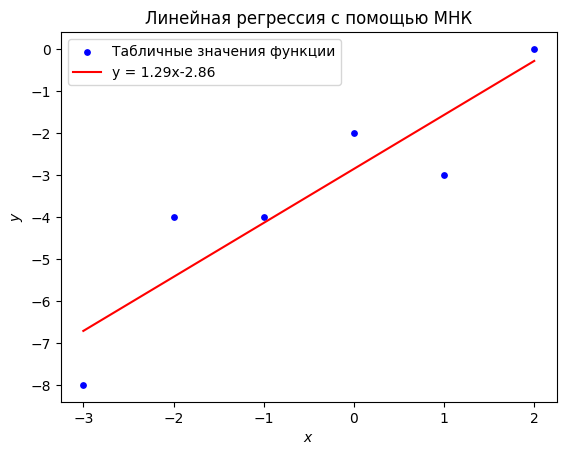

In [ ]:
x = np.array([-3, -2, -1,  0,  1, 2])
y = np.array([-8, -4, -4, -2, -3, 0])

graph_least_squares(x, y)

## Задача неточной интерполяции

В предыдущем разделе мы рассмотрели решение задачи линейной регрессии с помощью МНК. На практике число параметров $m$ в этой задаче обычно бывает небольшим. Дело в том, что в предметных областях, служащих источниками регрессионных задач, чаще всего используются двух- и трёхпараметрические модели. Трудно представить себе какую-то реальную, скажем, физическую модель, включающую, например, пять произвольных параметров, которые необходимо подбирать на основе экспериментальных данных. Очевидно, что теоретическое значение такой модели незначительно: имея "в руках" пять произвольных параметров, можно смоделировать практически что угодно. Что касается моделей с $m\geq 10$, то они совершенно бесполезны. Таким образом, **в задачах линейной регрессии** почти всегда $m=2$ или $m=3$.

Мы уже говорили, что в вычислительной математике МНК редко рассматривается как регрессионный метод; решение задач регрессии является, скорее, предметом статистики и анализа данных. С другой стороны, одно из центральных мест в вычислительной математике занимает **задача интерполяции**. Она ставится следующим образом.

Дана таблица значений $\big\{(x_i, y_i)\big\}_{i=0}^n$ (неизвестной) **функции-оригинала** $y=y(x)$. Требуется построить по этой таблице непрерывную **функцию-образ** $F=F(x)$ (**интерполянт**) так, чтобы $y_i=F(x_i)$. Более подробно с постановкой задачи интерполяции и методами её решения мы познакомимся на следующих семинарах. Пока отметим только, что весьма часто интерполянт $F=F(x)$ ищется в виде обобщённого полинома по некоторой системе базисных функций $\varphi_j(x)$ (далее нам будет удобнее нумеровать базисные функции и точки $x_i$, начиная с нуля):

$$F(x;\textbf{w})=\sum\limits_{j=0}^{m} w_j\varphi_j(x).$$

Принципиальное отличие этой задачи от задачи линейной регрессии состоит в **расстановке приоритетов**. Когда речь идёт о регрессии, то и количество, и вид базисных функций оказываются тесно связанными с моделью, поступающей из предметной области. Если физическая теория даёт, например, линейную по $x$ модель $F(x;a,b)=ax+b$ для зависимости $y=y(x)$, то нельзя просто так заменить эту модель какой-то другой моделью; нельзя взять, скажем, квадратичную по $x$ модель $F(x;a,b,c)=ax^2+bx+c$ и построить трёхпараметрическую регрессию. Подобная замена необоснованна, даже если вторая модель приводит к меньшему значению функционала $\text{RSS}$ по сравнению с первой моделью (т.е. даже если вторая кривая "ложится на точки" лучше первой). Цель регрессии — путём подгонки параметров найти наилучшую (например, в смысле минимизации функционала $\text{RSS}$) функцию **среди функций фиксированного вида**. При этом допускается, что эта наилучшая функция не будет строго удовлетворять всем условиям $y_i=F(x_i;\textbf{w})$ (часто она вообще не удовлетворяет ни одному из них — см. график из задачи 5). Иначе говоря, **в приоритете оказывается вид функции** $F(x_i;\textbf{w})$, потому что он диктуется некоторой моделью из предметной области.

Если же решается задача интерполяции, то **приоритетным является строгое выполнение всех условий** $y_i=F(x_i;\textbf{w})$. Вид функции $F$ и количество параметров $m$ при этом не конкретизируются: можно брать столько базисных функций $\varphi_j(x)$, сколько требуется, главное — воспроизвести всю таблицу значений $\big\{(x_i, y_i)\big\}_{i=0}^n$. Чтобы подчеркнуть это обстоятельство, сформулированную выше задачу интерполяции нередко называют задачей **точной** интерполяции.

Указанное различие важно чётко понимать во избежание подмены одной задачи другой. Известно, например, что при обработке результатов выполнения лабораторных работ по физике начинающие иногда выбирают для приближения экспериментальных точек полиномы высоких степеней, чтобы "кривая лучше легла на точки". Эта ошибка связана именно с неверной расстановкой приоритетов (задача регрессии подменяется задачей интерполяции): при обработке данных нет цели провести **какую-то** кривую так, чтобы охватить ею как можно больше точек, а есть цель построить **вполне определённую** кривую наилучшим образом (скажем, по МНК). Напротив, при интерполяции вид кривой не фиксируется, зато ставится задача провести кривую строго через **все** точки.



Бывает, однако, так, что методы точного интерполирования неприменимы: например, приближаемая функция не обладает достаточной гладкостью и для неё не удаётся построить интерполяционный полином или сплайн (что такое сплайн, мы узнаем на одном из следующих семинаров). В этом случае от требования удовлетворить всем условиям $y_i=F(x_i;\textbf{w})$ отказываются и формулируют какое-то другое требование — например, минимизировать тот же функционал $\text{RSS}$, что и в задаче линейной регрессии. Возникает задача **неточной интерполяции**. Внешне она тождественна с задачей линейной регрессии (основные формулы не меняются), но **существенное различие** всё же **остаётся**: в задаче регрессии параметров обычно два-три и вид базисных функций фиксирован, а в задаче неточной интерполяции система базисных функций и их количество априорно не регламентированы.

После сказанного может показаться, что для решения задачи неточной интерполяции достаточно применить тот же МНК, что и для построения линейной регрессии, т.е. достаточно последовательно выполнить следующие шаги:

* выбрать систему из $m<n$ базисных функций $\varphi_j(x)$ так, чтобы векторы $\boldsymbol{\varphi}_j$ были линейно независимыми,
* составить из столбцов $\boldsymbol{\varphi}_j$ матрицу $\textbf{G}_\varphi$,
* перейти от СЛАУ $\textbf{G}_\varphi\textbf{w}=\textbf{y}$ к симметризованной по Гауссу СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$ с матрицей Грама $\boldsymbol{\Gamma}=\textbf{G}_\varphi^\text{T}\textbf{G}_\varphi$ и вектором правой части $\textbf{g}=\textbf{G}_\varphi^\text{T}\textbf{y}$,
* решить полученную СЛАУ; решение будет единственным в силу теоремы 7.

Этот алгоритм кажется привлекательным в силу своей простоты, и при вычислениях с бесконеными десятичными дробями он действительно применим. Однако нужно учесть одну особенность, связанную с выбором базисных функций $\varphi_j(x)$, существенно осложняющую решение задачи.

Дело в том, что при произвольном выборе функций $\varphi_j(x)$ СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$ может оказаться очень плохо обусловленной; в этом случае её численное решение становится затруднительным. Так, упоминавшаяся выше система функций

$$1,\quad x,\quad x^2,\quad \dots,\quad x^p$$

уже при $p>5$ приводит к настолько плохо обусловленной системе, что её решение, найденное по МНК, не имеет смысла. В задаче линейной регрессии с этим затруднением обычно не сталкиваются, так как модели типа

$$F(x;\textbf{w})=w_0+w_1x+w_2x^2+w_3x^3+w_4x^4+w_5x^5$$

с шестью произвольными параметрами, как правило, не используются в качестве регрессионных (мы уже отмечали это в начале раздела). Однако в задаче неточной интерполяции нет какого-то принципиального ограничения на степень приближающего алгебраического полинома, что и объясняет возникновение трудности: **с увеличением степени интерполяционного многочлена ухудшается обусловленность СЛАУ, получаемой в МНК**. Этот эффект мы видели на первом семинаре, когда на конкретных примерах иллюстрировали важность знакомства с теорией численных методов (см. пример 2 из раздела "Введение").

Итак, **на практике при решении задачи неточной интерполяции с помощью МНК недостаточно требовать линейной независимости векторов** $\boldsymbol{\varphi}_j$: хотя единственный вектор весов $\textbf{w}$ и будет существовать, найти его численно с приемлемой точностью будет затруднительно в силу плохой обусловленности задачи. Решение этой проблемы подсказывается следующим наблюдением.

Заметим, что если векторы $\boldsymbol{\varphi}_j$ попарно ортогональны, т.е.

$$(\boldsymbol{\varphi}_k, \boldsymbol{\varphi}_l)=0,\quad k\neq l,$$

то матрица Грама $\boldsymbol{\Gamma}$ оказывается диагональной и решение СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$ находится очень просто:

$$w_j=\frac{g_j}{\gamma_{jj}}=\frac{(\boldsymbol{\varphi}_j, \textbf{y})}{(\boldsymbol{\varphi}_j, \boldsymbol{\varphi}_j)}=\frac{\displaystyle\sum\limits_{i=0}^n\varphi_j(x_i)y_i}{\displaystyle\sum\limits_{i=0}^n\varphi_j^2(x_i)},\quad j=0,\,1,\,\dots,\,m.$$

Это наводит на мысль выбирать базисные функции $\varphi_j(x)$ так, чтобы система векторов $\boldsymbol{\varphi}_j$ была **ортогональна** (а значит, и линейно независима) или по крайней мере **близка к ортогональной**. Тогда матрица Грама окажется "почти диагональной" и обусловленность СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$ будет достаточно хорошей.

В качестве базисных функций, удовлетворяющих указанному условию, обычно рекомендуют выбирать некоторую систему **ортогональных многочленов**. В вычислительной математике широко применяются, например, **многочлены Чебышёва первого рода**. Они определяются формулой

$$T_k(x)=\cos(k\arccos{x}),\quad k=0,\,1,\,\dots,\quad x\in [-1,1].$$

Можно показать, что для этих функций справедливо рекуррентное соотношение

$$T_{k+1}(x)=2xT_k(x)-T_{k-1}(x).$$

Для наглядности выпишем несколько первых многочленов Чебышёва:

$$T_0(x)=1,\quad T_1(x)=x,\quad T_2(x)=2x^2-1,\quad T_3(x)=4x^3-3x,\quad T_4(x)=8x^4-8x^2+1.$$

Многочлены Чебышёва обладают целым рядом любопытных свойств (которые мы ещё будем обсуждать при рассмотрении точной интерполяции функций). В частности, они **ортогональны с весом** (в смысле скалярного произведения в пространстве вещественнозначных функций, интегрируемых с квадратом по Риману):

$$\int\limits_{-1}^{1}\frac{dx}{\sqrt{1-x^2}}\,T_k(x)\,T_l(x)=
  \begin{cases}
    0,&\quad k\neq l,\\
    \pi/2,&\quad k=l>0,\\
    \pi,&\quad k=l=0.
  \end{cases}$$

Наличие уже этого свойства приводит к лучшей обусловленности СЛАУ, получаемой при использовании МНК, хотя речь здесь идёт об ортогональности в непрерывном случае — для функций, — а не в интересующем нас дискретном случае — для векторов $\boldsymbol{\varphi}_j$, которые при $\varphi_j(x)=T_j(x)$ имеют компоненты $T_j(x_i)$.

При специальном выборе точек $\{x_i\}_{i=0}^n$ можно добиться ортогональности и в интересующем нас смысле:

$$\sum\limits_{i=0}^nT_k(x_i)\,T_l(x_i)=0,\quad k\neq l.$$

Оказывается, для этого надо взять в качестве узлов $\{x_i\}_{i=0}^n$ нули многочлена Чебышёва $(n+1)$-го порядка. Доказательство этого утверждения мы предоставляем читателю.

**Упражнение.** Известно, что нули любого многочлена Чебышёва действительны, различны и расположены на интервале $(-1,1)$. Обозначим нули многочлена Чебышёва $T_{n+1}(x)$ через $\xi_i$. Ясно, что их количество совпадает со степенью многочлена, т.е. равно $n+1$. Докажите, что

$$\frac{2}{n+1}\sum\limits_{i=0}^nT_k(\xi_i)\,T_l(\xi_i)=\delta_{kl},\quad k,\,l=0,\,1,\,\dots,\,n,$$

т.е. **многочлены Чебышёва ортогональны на нулях более старших многочленов**.

*Указание.* Из определения многочленов Чебышёва найдите формулу для нулей $\xi_i$ и получите с её помощью равенство вида $T_k(\xi_i)=\cos(\dots)$. Затем с помощью тригонометрических тождеств преобразуйте левую часть равенства из упражнения к виду

$$\#\sum\limits_{i=0}^n\cos(\dots)+\#\sum\limits_{i=0}^n\cos(\dots)$$

(знак $\#$ заменяет некий коэффициент). Выясните, при каких условиях на $k$ и $l$ получившиеся суммы обращаются в нуль. Для этого Вам понабится утверждение из следующего упражнения.

**Упражнение.** Докажите, что для любых натуральных $n$ и $N$, а также любого действительного $\varphi$ верно равенство

$$\sum\limits_{q=0}^n\exp\bigg(2\pi i\frac{qN}{n+1}+i\varphi\bigg)=0.$$

Получите из этой формулы следствия для действительной и мнимой частей (при $N\neq 0$).

*Указание.* Рассмотрите комплексные корни уравнения $z^{n+1}=1$.

Помимо многочленов Чебышёва можно выбирать в качестве базисных функций $\varphi_j(x)$ и другие ортогональные многочлены (скажем, **многочлены Лежандра**). Мы не будем останавливаться на соответствующих примерах — читатель сможет найти их в книге П.К. Суетина "Классические ортогональные многочлены" (см. список литературы).

Итак, рядом приёмов (специальным выбором базисных функций и точек $\{x_i\}_{i=0}^n$) всё-таки можно добиться хорошей обусловленности задачи неточной интерполяции, решаемой с помощью МНК. Однако эти приёмы удобны далеко не всегда. В связи с этим в современной вычислительной практике часто используются другие методы приближения функций.

## МНК в Python

Библиотеки Python предлагают несколько реализаций МНК, ориентированных на решение различных задач.

Функция ```lstsq``` из модуля ```linalg``` библиотеки ```numpy``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)) позволяет находить обобщённые решения переопределённых СЛАУ. Она принимает на вход матрицу СЛАУ $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$ и вектор правой части $\textbf{f}$ (длины $n$). Обобщённое решение ищется как вектор $\textbf{u}$ (длины $m$), доставляющий минимум евклидовой норме вектора $\textbf{A}\textbf{x}-\textbf{f}$. Заметим, что

$$||\textbf{A}\textbf{x}-\textbf{f}||_3=\sqrt{(\textbf{A}\textbf{x}-\textbf{f}, \textbf{A}\textbf{x}-\textbf{f})}=\sqrt{\Phi(\textbf{x})},$$

где $\Phi(\textbf{x})$ — целевой функционал, соответствующий переопределённой СЛАУ. Отсюда следует, что метод, реализуемый функцией ```lstsq```, представляет собой не что иное, как МНК (см. определения 2 и 3).

Функция ```lstsq``` возвращает не только найденный вектор $\textbf{u}$, но и минимальное значение функционала $\Phi(\textbf{x})$, которое достигается на этом векторе, а также ранг матрицы $\textbf{A}$ и вектор из её сингулярных чисел $\sigma_i$, упорядоченных по невозрастанию. Пример с переопределённой СЛАУ из задачи 4:

In [11]:
import numpy as np

A = [ [1, 1],
      [2, 1],
      [1, 2] ]
f = [1, 2, 3]

np.linalg.lstsq(A, f)

(array([0.27272727, 1.27272727]),
 array([0.36363636]),
 np.int32(2),
 array([3.31662479, 1.        ]))

Ранг матрицы $\textbf{A}$ определяется по количеству ненулевых сингулярных чисел. При этом по желанию пользователя могут быть отброшены сингулярные числа, близкие к нулю: сигнатура функции предусматривает возможность передать необязательный аргумент ```rcond```, устанавливающий **относительный порог** для сингулярных чисел. Если $\sigma_i<\text{rcond}\cdot \sigma_\text{max}$ (где $\sigma_\text{max}$ — максимальное сингулярное число матрицы $\textbf{A}$), то при определении ранга это $\sigma_i$ будет рассматриваться как нулевое, т.е. **эффективный ранг** матрицы уменьшится. По умолчанию $\text{rcond}=\varepsilon_\text{маш}\cdot\max(n,m)$, т.е. если $n\geq m$, то $\text{rcond}=\varepsilon_\text{маш}\cdot n$ (чем больше уравнений содержит СЛАУ, тем выше порог).

Поясним, для каких целей может понадобиться изложенная выше процедура с "отсечением" сингулярных чисел и определением эффективного ранга. Дело в том, что функцию ```lstsq``` можно вызывать не только в случае $n>m$, отвечающем переопределённой СЛАУ, но и при $n=m$ (и даже при $n<m$, когда СЛАУ является недоопределённой). Очевидно, что при $n=m$ обобщённое решение СЛАУ $\textbf{u}$ совпадает с её классическим решением, причём $\Phi(\textbf{u})=0$.

Пусть решается СЛАУ

$$\begin{cases}
    (1-\varepsilon)x_1 + x_2=2-\varepsilon,\\
    x_1 + (1-\varepsilon)x_2=2-\varepsilon
  \end{cases}$$

(не являющаяся переопределённой). Ясно, что её точное решение есть единичный вектор. Попробуем найти это решение при различных $\varepsilon$ с помощью уже известной нам функции ```solve```:

In [12]:
def eps_with_solve(eps: float):
    A = [ [1 - eps, 1],
          [1, 1 - eps] ]
    f = [2 - eps, 2 - eps]

    try:
        x = np.linalg.solve(A, f)
        return x
    except Exception as e:
        print(e)

Будем уменьшать величину $\varepsilon$, последовательно придавая ей значения $10^{-1}$, $10^{-2}$ и т.д. до $10^{-20}$:

In [13]:
from ipywidgets import interact, FloatLogSlider

eps_w = FloatLogSlider(min=-20, max=-1, step=1, base=10, value=0.1)

interact(eps_with_solve, eps=eps_w);

interactive(children=(FloatLogSlider(value=0.1, description='eps', max=-1.0, min=-20.0, step=1.0), Output()), …

Начиная с $\varepsilon=10^{-17}$, функция ```solve``` выдаёт ошибку в связи с вырожденностью матрицы. Так получается потому, что при очень малых $\varepsilon$ строки (и столбцы) матрицы оказываются практически линейно зависимыми. На фоне неизбежных ошибок округления величина $\varepsilon$ теряется, в результате чего матрица рассматривается как вырожденная.

Если же подать указанную СЛАУ на вход функции ```lstsq```, то решение будет найдено верно при любом $\varepsilon$:

In [14]:
def eps_with_lstsq(eps: float):
    A = [ [1 - eps, 1],
          [1, 1 - eps] ]
    f = [2 - eps, 2 - eps]

    return np.linalg.lstsq(A, f)
    # return np.linalg.lstsq(A, f, rcond=1e-10)

In [15]:
eps_w = FloatLogSlider(min=-20, max=-1, step=1, base=10, value=0.1)

interact(eps_with_lstsq, eps=eps_w);

interactive(children=(FloatLogSlider(value=0.1, description='eps', max=-1.0, min=-20.0, step=1.0), Output()), …

Видно, что при $\varepsilon\leq 10^{-16}\sim\varepsilon_\text{маш}$ меньшее сингулярное число полагается равным нулю, а эффективный ранг матрицы уменьшается с двойки до единицы. При этом матрица СЛАУ автоматически приближается матрицей меньшего ранга путём "обрезки" матриц-сомножителей в сингулярном разложении $\textbf{A}=\textbf{U}\boldsymbol{\Sigma}\textbf{V}^\dagger$ (эту процедуру мы уже рассматривали во введении к третьему семинару). Таким образом, возникает, по существу, **недоопределённая СЛАУ** с $n=1$ и $m=2$. К ней применяется МНК, с помощью которого и находится верное решение. В приведённом примере аргумент ```rcond``` не задавался, и поэтому использовалось его значение по умолчанию. Увеличение этого параметра (например, до значения $10^{-10}$, как в комментированной строке) позволяет выполнить "переключение на меньший ранг" раньше, чем ошибки округления сравняются с $\varepsilon$. В некоторых задачах такой приём может оказаться полезным.

Подчеркнём, что **обобщённые решения** (в смысле определения 3) **существуют и у недоопределённых СЛАУ** ($n<m$), правда, **оказываются не единственными**. В подобных случаях функция ```lstsq``` возвращает то из обобщённых решений, которое имеет наименьшую евклидову норму. Пример:

In [16]:
B = [ [1, 1, 1],
      [1, 1, 0] ]
b = [3, 2]

np.linalg.lstsq(B, b)

(array([1., 1., 1.]),
 array([], dtype=float64),
 np.int32(2),
 array([2.13577921, 0.66215345]))

Аналогичная функция с тем же именем ```lstsq``` имеется в модуле ```linalg``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html)):

In [17]:
import scipy as sp

sp.linalg.lstsq(A, f)

(array([0.27272727, 1.27272727]),
 np.float64(0.3636363636363639),
 2,
 array([3.31662479, 1.        ]))

Покажем, как можно применить функцию ```lstsq``` для построения линейной регрессии. Предварительно напишем функцию ```generate_data```, которая по заданной зависимости $f=f(x)$ строит $n$ точек с координатами $(x_i,f_i)$, а затем придаёт им случайные смещения (распределённые по нормальному закону) как вдоль оси абсцисс, так и вдоль оси ординат. Массивы случайных величин, выступающих в роли смещений, будем генерировать с помощью метода ```normal``` класса ```Generator``` ([документация](https://numpy.org/doc/stable/reference/random/generator.html)) из модуля ```random``` библиотеки ```numpy```. Для создания экземпляра класса требуется передать конструктору некоторый битовый генератор — например, конгруэнтный генератор с перестановкой, реализованный в виде функции ```np.random.PCG64``` ([документация](https://numpy.org/doc/stable/reference/random/bit_generators/pcg64.html)). Величины смещений точек будем регулировать, задавая дисперсии распределений:



In [18]:
from types import FunctionType
import matplotlib.pyplot as plt

def generate_data(n: int, f: FunctionType,
                  shift_x: float = 0.5, shift_y: float = 0.5,
                  graph: bool = False):
    # линейная зависимость y=y(x)
    x = np.linspace(0, 10, n)
    func = np.vectorize(f)
    y = func(x)

    # наложение на точки случайных сдвигов
    gen = np.random.Generator(np.random.PCG64())
    x_shift = gen.normal(loc=0, scale=shift_x, size=n)
    y_shift = gen.normal(loc=0, scale=shift_y, size=n)
    x = x + x_shift
    y = y + y_shift

    # визуализация построенных данных
    if graph:
        fig, ax = plt.subplots()
        ax.scatter(x, y, s=10, c='b')

        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")
        plt.title("Данные для линейной регрессии")
        plt.show()

    return x, y

Для примера возьмём квадратичную по $x$ функцию $f(x)=2x^2+3x+1$ (пользуясь терминологией из предыдущего раздела, можно сказать, что это функция-оригинал, которая на практике никогда не бывает известной). Сгенерируем 40 "экспериментальных точек" и для наглядности отобразим их на графике:

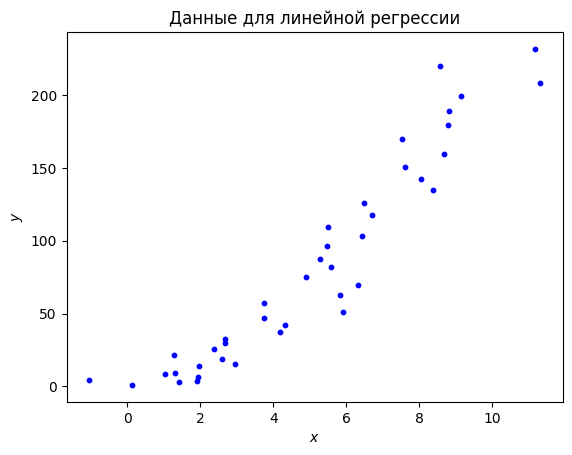

In [19]:
f = lambda xi: 2 * xi**2 + 3 * xi + 1
x, y = generate_data(n=40, f=f, shift_x=1.0, shift_y=0.7, graph=True)

Заметим, между прочим, что из графика трудно установить степень полинома, соответствующего зависимости между $x$ и $y$: "на глаз" кажется, что данные можно приблизить и линейным законом. Подчеркнём ещё раз, что **конкретный вид используемой модели входит в формулировку задачи регрессии** (а она поступает из предметной области). Далее мы будем пользоваться трёхпараметрической моделью $F(x)=ax^2+bx+c$.

Мы видели, что, когда в качестве функции $F$ используется алгебраический полином, столбцы матрицы $\textbf{G}_\varphi$ переопределённой СЛАУ представляют собой степени $x^0$, $x^1$, $x^2$ и т.д., вычисленные в точках $\{x_i\}_{i=0}^n$. Для построения такой матрицы можно применить широко использующуюся в ```numpy``` **технику срезов** (документация: [первая ссылка](https://numpy.org/doc/stable/user/basics.indexing.html#slicing-and-striding), [вторая ссылка](https://numpy.org/doc/stable/user/basics.indexing.html#dimensional-indexing-tools)). Если дан одномерный массив, то можно формально взять срез по двум измерениям (```axis=0``` и ```axis=1```) с объектом ```None``` в качестве диапазона индексов столбцов. Такой вызов эквивалентен добавлению к массиву новой оси (нового измерения). В случае одномерного массива вектор-строка превратится в вектор-столбец:

In [20]:
arr = np.array([1, 2, 3, 4, 5])
arr = arr[:, None]
arr

array([[1],
       [2],
       [3],
       [4],
       [5]])

Подобные конструкции применяются довольно часто, в связи с чем для объекта ```None``` даже создан специальный псевдоним ```np.newaxis``` ([документация](https://numpy.org/doc/stable/reference/constants.html#numpy.newaxis)). Его удобно использовать в коде — так программа становится более ясной:

In [21]:
arr = np.array([1, 2, 3, 4, 5])
arr = arr[:, np.newaxis]
arr

array([[1],
       [2],
       [3],
       [4],
       [5]])

К получившемуся столбцу можно применить конструкцию вида ```arr • [l1, l2, ...]```, где точка означает некоторую бинарную операцию. В результате получится матрица с количеством столбцов, равным длине одномерного массива, причём ко всем элементам первого столбца будет применена бинарная операция ```•``` с элементом ```l1``` в качестве второго аргумента, ко всем элементам второго столбца — бинарная операция с элементом ```l2``` и т.д. Примеры:

In [22]:
arr + [3, 5, 7]

array([[ 4,  6,  8],
       [ 5,  7,  9],
       [ 6,  8, 10],
       [ 7,  9, 11],
       [ 8, 10, 12]])

In [23]:
arr < [3, 5, 7]

array([[ True,  True,  True],
       [ True,  True,  True],
       [False,  True,  True],
       [False,  True,  True],
       [False, False,  True]])

Очень легко, таким образом, создать копии столбцов с величинами $\{x_i\}_{i=0}^n$, возведёнными в целые неотрицательные степени, как это требуется в рассматриваемой задаче приближения алгебраическим полиномом. Например:

In [24]:
arr ** [2, 3, 4]

array([[  1,   1,   1],
       [  4,   8,  16],
       [  9,  27,  81],
       [ 16,  64, 256],
       [ 25, 125, 625]])

Итак, программа для построения регрессии, использующая функцию ```lstsq```, может выглядеть так:

In [25]:
def regr_poly2(x: np.ndarray, y: np.ndarray):
    # подбор коэффициентов по МНК
    G = x[:, np.newaxis] ** [0, 1, 2]
    w, Phi, rank, sing = np.linalg.lstsq(G, y)

    # построение регрессионной кривой
    F = lambda xi: w[0] + w[1] * xi + w[2] * xi**2
    func = np.vectorize(F)
    grid = np.arange(np.floor(np.min(x)), np.ceil(np.max(x)) + 0.01, 0.01)
    regr_line = func(grid)

    # предыдущий блок можно реализовать так:
    # grid = np.arange(np.floor(np.min(x)), np.ceil(np.max(x)) + 0.01, 0.01)
    # regr_line = np.polyval(np.flip(w), grid)

    # визуализация
    fig, ax = plt.subplots()
    ax.scatter(x, y, s=10, c='b', label='Данные') # данные
    ax.plot(grid, regr_line, c='g',
            label='y = {:.2f}$x^2${:+.2f}$x${:+.2f}'.format(w[2], w[1], w[0])) # подобранная кривая

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend()

    plt.title("Линейная регрессия в модели $y=ax^2+bx+c$")

    plt.show()

При построении регрессионной кривой можно было бы вычислить значения найденного алгебраического полинома с помощью функции ```np.polyval``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polyval.html)). Она принимает на вход массив коэффициентов полинома (начиная с коэффициента при старшей степени) и сетку, в узлах которой необходимо найти значения полинома. Поскольку в нашей программе принят другой порядок коэффициентов в векторе $\textbf{w}$ (от нулевой степени к старшей), перед подачей этого вектора в функцию ```np.polyval``` мы применили функцию ```np.flip``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.flip.html)) для реверсии массива.

Результат работы программы:

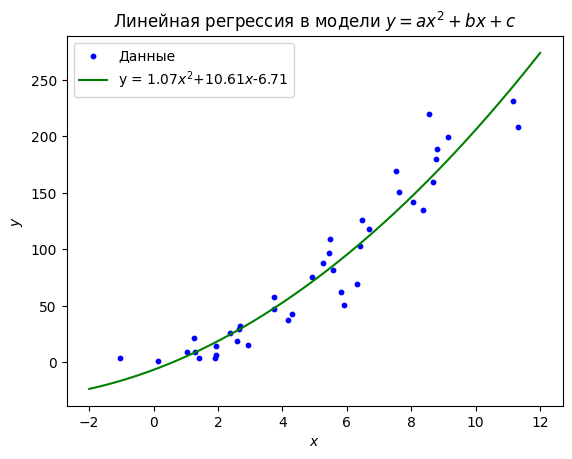

In [26]:
regr_poly2(x, y)

Тот же результат (те же параметры $a$, $b$ и $c$) можно было бы получить с помощью функции ```np.polyfit``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html)). Она принимает на вход два массива, образующих таблицу данных $\big\{(x_i, y_i)\big\}_{i=0}^n$, и степень алгебраического полинома, который необходимо использовать в качестве регрессионной модели:

In [27]:
np.polyfit(x, y, 2)

array([ 1.06523861, 10.60684446, -6.71133436])

Если передать необязательный аргумент ```full=True```, то кроме подобранных параметров будет выведена дополнительная информация о результатах применения МНК:

In [28]:
np.polyfit(x, y, 2, full=True)

(array([ 1.06523861, 10.60684446, -6.71133436]),
 array([15416.30552802]),
 np.int32(3),
 array([1.64134206, 0.53960825, 0.12173402]),
 np.float64(8.881784197001252e-15))

Как и в случае функции ```lstsq```, вывод содержит минимальное значение целевого функционала, эффективный ранг матрицы переопределённой СЛАУ, а также список её сингулярных чисел. Последним выведен относительный порог ```rcond```.

Функция ```np.polyfit``` является в некотором смысле устаревшей, хотя до сих пор используется весьма широко. Современные версии библиотеки ```numpy``` содержат специальный пакет ```polynomial``` ([документация](https://numpy.org/doc/stable/reference/routines.polynomials-package.html)), включающий шесть классов для приближения функций обобщёнными полиномами с помощью МНК. Каждый класс строит обобщённый полином по некоторой системе классических многочленов:

* класс ```Polynomial``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html)) реализует приближения алгебраическими полиномами (отрезками степенных рядов),
* класс ```Chebyshev``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.chebyshev.Chebyshev.html)) реализует приближения обобщёнными полиномами по системе ортогональных многочленов Чебышёва (первого рода),
* класс ```Legendre``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.legendre.Legendre.html)) — то же с многочленами Лежандра,
* класс ```Laguerre``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.laguerre.Laguerre.html)) — то же с многочленами Лагерра,
* классы ```Hermite``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.hermite.Hermite.html)) и ```HermiteE``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.hermite_e.HermiteE.html)) — то же с многочленами Эрмита.

Два класса для многочленов Эрмита введены в связи с тем, что на практике эти многочлены одинаково часто используют в двух различных видах (эквивалентных с принципиальной точки зрения):

$$\text{H}_n(x)=(-1)^ne^{x^2}\frac{d^n}{dx^n}e^{-x^2},\quad \text{He}_n(x)=(-1)^ne^{x^2/2}\frac{d^n}{dx^n}e^{-x^2/2}.$$

Первое определение часто встречается в теоретической физике, второе — в статистике. Обозначение $\text{He}_n(x)$ характерно, скорее, для англоязычной литературы.



Выполним с помощью пакета ```polynomial``` "фит" ранее сгенерированных данных. Как и выше, выбираем регрессионную в модель в виде алгебраического полинома второй степени (класс ```Polynomial```):

In [29]:
F = np.polynomial.Polynomial.fit(x, y, 2)
F

Polynomial([ 75.69391655, 133.00955595,  40.64816061], domain=[-1.04920954, 11.30534228], window=[-1.,  1.], symbol='x')

Пользоваться приближающим многочленом в таком виде не очень удобно. Преобразование к стандартному виду осуществляется методом ```convert``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.convert.html)):

In [30]:
F = F.convert()
F

Polynomial([-6.71133436, 10.60684446,  1.06523861], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Для получения массива коэффициентов надо обратиться к атрибуту ```coef``` созданного экземпляра класса ```Polynomial```:

In [31]:
F.coef

array([-6.71133436, 10.60684446,  1.06523861])

Этот вызов эквивалентен применению функции ```np.polyfit``` к исходным данным (только коэффициенты многочлена выдаются в другом порядке — начиная с нулевой степени). На практике лучше отдавать предпочтение именно классу ```Polynomial```, поскольку использованная в нём реализация МНК характеризуется лучшей численной устойчивостью.

Очень удобно, что все шесть классов из пакета ```polynomial``` содержат методы анализа обобщённых полиномов. При необходимости, можно, например, найти корни построенного полинома (метод ```roots``` — [документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.roots.html)):

In [32]:
F.roots()

array([-10.55419593,   0.59694845])

Доступны также его дифференцирование (метод ```deriv``` — [документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.deriv.html)) и интегрирование (метод ```integ``` — [документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.integ.html)):

In [33]:
dF = F.deriv(1)
dF.convert()

Polynomial([10.60684446,  2.13047722], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [34]:
integ_F = F.integ(1, 2025) # второй аргумент - произвольная постоянная интегрирования
integ_F.convert()

Polynomial([ 2.02500000e+03, -6.71133436e+00,  5.30342223e+00,  3.55079536e-01], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Для более подробного ознакомления с возможностями пакета ```polynomial``` рекомендуем обратиться к документации, на которую мы ссылались выше.

Полезно знать, что и сами обобщённые многочлены (Чебышёва, Лежандра и др.) также имеют готовые реализации в Python. Их можно найти в модуле ```special``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/special.html)) наряду с большим количеством других специальных функций. Приведём ссылку на раздел документации, посвящённый именно ортогональным многочленам: [ссылка](https://docs.scipy.org/doc/scipy/reference/special.html#orthogonal-polynomials). Познакомиться с этим разделом читатель сможет самостоятельно. Мы ограничимся только указанием на весьма полезную функцию, позволяющую получить массив корней обобщённого многочлена заданной степени. Для примера возьмём многочлен Чебышёва пятой степени:

In [35]:
roots, weights = sp.special.roots_chebyt(5)
roots

array([-0.95105652, -0.58778525,  0.        ,  0.58778525,  0.95105652])

Функция ```roots_chebyt``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.roots_chebyt.html)) выдаёт не только нули многочлена $T_n(x)$, но и веса для так называемой квадратурной формулы Гаусса—Чебышёва (это метод численного интегрирования). В контексте задачи неточной интерполяции нас интересуют именно нули. Элементы полученного массива ```roots``` можно использовать в качестве точек $\{x_i\}_{i=0}^n$ (если, конечно, при построении приближения функции-оригинала есть возможность распоряжаться выбором этих точек). В предыдущем разделе мы уже говорили, в чём заключается достоинство такой системы узлов.

Для наглядности приведём также графики нескольких первых многочленов Чебышёва. Заодно продемонстрируем использование функции ```eval_chebyt``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.eval_chebyt.html)), предназначенной для вычисления значений многочлена $T_n(x)$ заданной степени $n$ в указанной точке (или точках):

In [36]:
def graph_Chebyshev_polynomials(k: int):
    grid = np.arange(-1, 1 + 0.01, 0.01)

    fig, ax = plt.subplots()

    for i in range(k):
        y = sp.special.eval_chebyt(i, grid)
        ax.plot(grid, y, label=i)

        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    ax.legend(title="Степень $n$", loc="upper left", bbox_to_anchor=(1, 1))

    plt.title("Графики многочленов Чебышёва $y=T_n(x)$")

    plt.show()

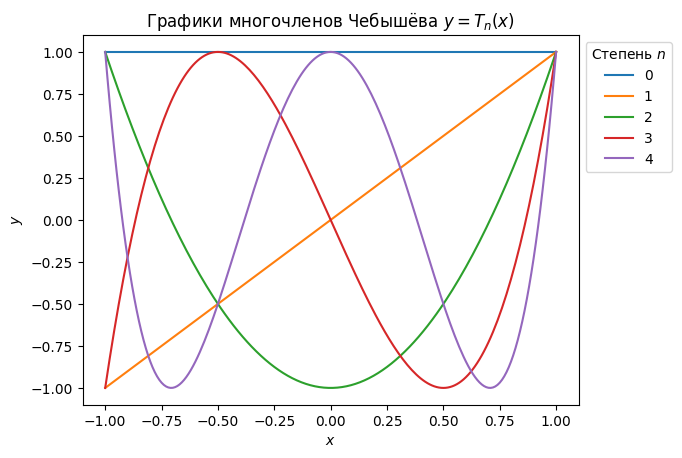

In [37]:
graph_Chebyshev_polynomials(5)

В связи с упоминанием функции ```eval_chebyt``` отметим, что **вызов этой функции** (и аналогичных функций для других многочленов, в том числе "обычных" алгебраических) **всегда следует предпочитать вычислению значения многочлена "вручную"**. Пусть, например, требуется найти значение многочлена Чебышёва $T_{n}(x)$ в точке $x=a$. Можно было бы сначала получить коэффициенты этого многочлена с помощью атрибута ```c``` класса ```np.poly1d``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.poly1d.html)), экземпляром которого является объект, выдаваемый функцией ```sp.special.chebyt``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.chebyt.html)), а потом найти искомую величину $T_n(a)$, умножив степени $a$ на полученные коэффициенты:

In [38]:
def calc_Chebyshev(n: int, a: float):
    degs = [ a**i for i in range(n+1) ]
    coeffs = sp.special.chebyt(n).c

    return coeffs @ np.flip(degs)

Однако такой способ расчёта оказывается численно неустойчивым, особенно при высоких степенях многочлена $n$. Убедимся в этом так: будем вычислять значения $T_n(1)$ при различных $n$ и сравнивать результаты работы пользовательской функции ```calc_Chebyshev``` с результатами, полученными функцией ```eval_chebyt```. Из свойств многочленов Чебышёва следует, что для всех степеней $n$ должно иметь место равенство $T_n(1)=1$.

In [39]:
def compare_Chebyshev(n: int):
    print("Вычисление вручную: ", calc_Chebyshev(n, a=1))
    print("Вычисление с помощью встроенной функции: ", sp.special.eval_chebyt(n, 1))

In [ ]:
from ipywidgets import IntSlider

n_w = IntSlider(min=0, max=100, step=1, value=0)

interact(compare_Chebyshev, n=n_w);

interactive(children=(IntSlider(value=0, description='n'), Output()), _dom_classes=('widget-interact',))

Встроенные классы для работы с многочленами позволяют избежать подобных эффектов; они обеспечивают численную устойчивость вплоть до степеней $n\sim 10^4$. Об этом следует помнить и при работе с "обычными" алгебраическими многочленами: их лучше задавать в виде объектов упоминавшегося выше класса ```sp.polynomial.Polynomial``` (или более старого класса ```np.poly1d```), а не собирать "вручную" по коэффициентам.

Рассмотренные до сих пор реализации МНК относились к библиотеке ```numpy```. Функции, так или иначе связанные с МНК, содержит и библиотека ```scipy``` (точнее — её модуль ```optimize```). Мы не будем перечислять все такие функции: с ними можно познакомиться по [документации](https://docs.scipy.org/doc/scipy/reference/optimize.html#least-squares-and-curve-fitting). Ограничимся примером построения **нелинейной** регрессии с помощью функции ```sp.optimize.curve_fit``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)). В качестве данных возьмём таблицу результатов измерения индукции $B$ магнитного поля в зависимости от напряжённости поля $H$ (таблица заимствована из условия задачи, сформулированной в видеоразборе метода итерированного веса; мы рекомендовали посмотреть это видео в одном из предыдущих разделов — дублируем [ссылку](https://vkvideo.ru/video-212608323_456239026)).

In [40]:
H = np.array([   8,   10,   15,   20,   30,   40,   60,   80])
B = np.array([13.0, 14.0, 15.4, 16.3, 17.2, 17.8, 18.5, 18.8])

Чтобы "фитировать" эти данные нелинейной по параметрам зависимостью

$$B=\frac{H}{a+bH},$$

достаточно передать в ```curve_fit``` эту функцию и два массива с данными:

In [41]:
def B_func(H: float, a: float, b: float):
    return H / (a + b*H)

def regr_nonlin(x: np.ndarray, y: np.ndarray):
    # подбор параметров нелинейным МНК
    w, pcov = sp.optimize.curve_fit(B_func, H, B)

    # построение регрессионной кривой
    F = lambda xi: xi / (w[0] + w[1] * xi)
    func = np.vectorize(F)
    grid = np.arange(np.floor(np.min(x)), np.ceil(np.max(x)) + 0.01, 0.01)
    regr_line = func(grid)

    # визуализация
    fig, ax = plt.subplots()
    ax.scatter(x, y, s=10, c='b', label='Экспериментальные точки')
    ax.plot(grid, regr_line, c='magenta',
            label='B=H/({:.2f}{:+.2f}H)'.format(w[0], w[1]))

    ax.set_xlabel("$H/H_0$")
    ax.set_ylabel("$B/B_0$")
    ax.legend(loc="lower right")

    plt.title(r"Зависимость индукции B магнитного поля"
              "\n"
              r"от его напряжённости H")

    plt.show()

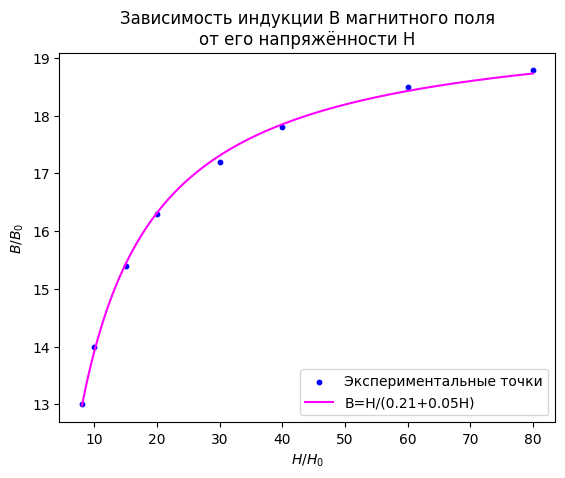

In [42]:
regr_nonlin(H, B)

Обсуждение (итерационного) метода, стоящего за функцией ```curve_fit``` (по сути, нелинейного МНК), потребовало бы от нас довольно пространного изложения основ теории оптимизации. Эта тема выходит за рамки семинара. Желающих познакомиться с теоретическими основами нелинейного МНК отсылаем к специальной литературе — например, к неплохой брошюре "Methods for Non-Linear Least Squares Problems" (см. список дополнительной литературы).

# Практические задачи

## Задача A

1.  Реализовать метод Якоби решения СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ в виде функции ```Jacobi_iter```. Функция должна принимать на вход три основных аргумента: матрицу СЛАУ $\textbf{A}$, вектор правой части $\textbf{f}$ и требуемую точность приближённого решения $\varepsilon$ (по умолчанию $\varepsilon=10^{-8}$). Возвращается единственный объект — одномерный массив, содержащий компоненты искомого приближённого решения СЛАУ. Предусмотреть предварительную проверку сходимости метода Якоби для заданной СЛАУ. При отсутствии сходимости возбуждать исключение ```ValueError``` с соответствующим комментарием. Желательно сделать проверку сходимости отключаемой путём добавления необязательного аргумента ```checking``` со значением ```True``` по умолчанию.

2. Выполнить сравнение реализованного метода Якоби с методом последовательных исключений Гаусса (в его пользовательской реализации), аналогичное сравнению МПИ с методом Гаусса, которое проводилось в конце предыдущего семинара. Именно, построить для обоих методов графики зависимости времени решения СЛАУ $t$ (в нс) от размерности СЛАУ $n$. Для теста использовать СЛАУ с симметричной положительно определённой матрицей, удовлетворяющей условию строгого диагонального преобладания (формула для элементов такой матрицы дана в заключительном разделе предыдущего семинара). Сделать выводы об эффективности методов.

3. Повторить пункты 1 и 2 для методов Зейделя и ПВР. Можно написать одну общую функцию ```SOR_iter``` с необязательным аргументом $\omega$, по умолчанию равным единице (поскольку при $\omega=1$ метод ПВР переходит в метод Зейделя). Выбор параметра $\omega$ для метода ПВР, отличного от метода Зейделя, остаётся на усмотрение читателя: можно выбирать его случайным из отрезка $1<\omega<2$ или сделать интерактивный график с ползунком для $\omega$.

4. Сравнить все три итерационных метода (Якоби, Зейделя и ПВР) между собой, построив аналогичный график с тремя кривыми.

5. Воспользовавшись примерами из задачи 2 (или примерами, подобранными самостоятельно), продемонстрировать на практике, что сходимость метода Якоби и сходимость метода Зейделя никак не связаны друг с другом (если размерность решаемой СЛАУ $n>2$).

При написании программ рекомендуется руководствоваться теми принципами реализации итерационных процессов, которые были разобраны на предыдущем семинаре.

## Задача B

Написать программу для решения СЛАУ

$$
  \begin{pmatrix}
    1 & 0 & 1/2 & 1/3 \\
    0 & 1 & 1/3 & 1/4 \\
    1/2 & 1/3 & 1 & 0 \\
    1/3 & 1/4 & 0 & 1
  \end{pmatrix}
  \begin{pmatrix}
    x_1 \\
    x_2 \\
    x_3 \\
    x_4
  \end{pmatrix}=
  \begin{pmatrix}
    67/60 \\
    31/30 \\
    23/20 \\
    67/60
  \end{pmatrix}
$$

методом последовательной верхней релаксации с параметром $\omega$. Построить график зависимости количества итераций $s$, необходимого для достижения заданной точности $\varepsilon$, от $\omega$. Определить по графику оптимальное значение параметра $\omega_\text{opt}$. Есть ли смысл решать данную СЛАУ итерационным методом?

## Задача C

Написать программу, которая принимает на вход координаты $n\geq 4$ точек плоскости и с помощью МНК строит по ним окружность. Визуализировать результат. Пользоваться встроенными реализациями МНК запрещается.

# Литература и другие источники

**Видеозаписи:**

1. Вычислительная математика — лекция 4. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/1MzfHvgqb78?si=bpiHgBxvgt-9TJEO&t=605) (YouTube).

2. Вычислительная математика — лекция 5. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/9yDoZU_WkuQ?si=FucSoS4marfSNVIz&t=73) (YouTube).

3. Вычислительная математика — лекция 6. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/BUTUuvs724M?si=Dflbqjl2AdyGauPC&t=3) (YouTube).

4. Вычислительная математика — лекция 5. Лектор — А.В. Чикиткин. [Ссылка](https://m.youtube.com/watch?v=vS_3zWYYFVg) (YouTube).

5. Методы Якоби и Зейделя решения СЛАУ — видеоразбор темы. Преподаватель — Н.И. Караваева. [Ссылка](https://vkvideo.ru/video-212608323_456239025) (VK Видео).

6. Метод наименьших квадратов — видеоразбор темы. Преподаватель — Г.С. Гойман. [Ссылка](https://vkvideo.ru/video-212608323_456239031) (VK Видео).

7. Итерационный взвешенный метод наименьших квадратов — видеоразбор задачи. Преподаватель — Н.И. Караваева. [Ссылка](https://vkvideo.ru/video-212608323_456239026) (VK Видео).

**Рекомендуемая литература (с комментариями):**

Изложение теории итерационных методов решения СЛАУ можно найти как в классических курсах по вычислительной математике, так и в монографиях по прикладной линейной алгебре. Приступая к чтению литературы, следует иметь в виду, что **в разных книгах одни и те же названия могут относиться к похожим, но, вообще говоря, различным итерационным методам** (чаще всего в разных смыслах употребляются названия "метод простых итераций" и "метод Зейделя"). Мы рекомендуем следующие учебники и монографии:

1.   *А.А. Самарский, А.В. Гулин. Численные методы.* Итерационным методам решения СЛАУ посвящена вторая глава книги (стр. 82—126). Примечательно, что в неё включено изложение некоторых сведений о многочленах Чебышёва (см. пятый параграф); правда, сделано это по причинам, совсем не связанным с МНК. Шестой параграф (как, впрочем, и пятый) при первом чтении можно пропустить (в нём разбираются оставшиеся за рамками семинара итерационные методы с чебышёвским набором параметров). Заслуживает внимания теорема 1 второго параграфа (стр. 86), дающая достаточное условие сходимости итерационных процессов, представленных в канонической форме; в других источниках эту теорему часто называют теоремой Самарского. В книге использована та же терминология, что и в тексте семинара (те же названия методов). Среди прочих источников в списке эта книга является, пожалуй, наилучшей в том смысле, что она наиболее удачно сочетает глубину и педагогичность изложения.  

2.  *Дж. Голуб, Ч. Ван Лоун. Матричные вычисления.* К теме семинара относится десятая глава монографии (стр. 452—481), в которой удачно изложена идея расщепления (в изложении авторов она положена в основу построения итерационных процессов). Поскольку книга, как мы уже отмечали, носит прикладной характер, приведённые в ней теоретические сведения по классическим методам (Якоби, Зейделя, ПВР) довольно скудны (но для наших целей вполне достаточны). С другой стороны, много места отведено важному методу сопряжённых градиентов (стр. 461—481), который не разбирался в тексте семинара. В конце каждого раздела можно найти обстоятельные списки литературы (правда, в основном журнальной англоязычной).

3.  *А.И. Лобанов, И.Б. Петров. Вычислительная математика: курс лекций.* Теоретические сведения по классическим итерационным методам (МПИ, методы Якоби, Зейделя и ПВР) изложены в пункте 2.5 второй лекции (стр. 54—61). Методам вариационного типа посвящён пункт 2.6 (стр. 61—67). Изложение носит конспективный характер и почти не выходит за рамки семинара в смысле объёма охватываемого материала. Исключение составляет пункт 2.6, в котором более подробно изложены методы наискорейшего спуска и минимальных невязок, а также разобран метод сопряжённых градиентов. Напомним, что помимо указанного учебника существует книга тех же авторов с похожим названием: "Лекции по вычислительной математике" (издание 2006 г.). Лучше пользоваться названной выше книгой (издания 2021 г.). В более новом учебнике устранены замеченные опечатки, а материал отдельных лекций значительно переработан.

4. *В.И. Косарев. 12 лекций по вычислительной математике.* На прошлом семинаре мы уже рекомендовали третью лекцию (стр. 38—50) из этого курса в связи с изучением МПИ. В той же лекции очень лаконично изложены методы Якоби и Зейделя. К сожалению, совершенно не упоминается метод ПВР. В силу малой подробности изложения этот источник можно рекомендовать лишь как быстрое введение в тему. Зато текст читается очень легко. В конце лекции (после дополнений) приведён список литературы, по которой итерационные методы можно изучить более подробно.

5. *Л. Хейгеман, Д. Янг. Прикладные итерационные методы.* Эта книга **целиком** посвящена итерационным методам решения СЛАУ, что выгодно отличает её от других учебников и монографий, в которых той же теме отведено лишь несколько глав. На протяжении всей книги рассматриваются пять основных методов, в том числе МПИ (он фигурирует под названием "метод Ричардсона"), методы Якоби, Зейделя и ПВР. Основные сведения об этих методах собраны во второй главе (стр. 31—54), и для нужд общего курса вычислительной математики достаточно её выборочного прочтения (при необходимости можно периодически обращаться к первой главе, носящей справочный характер). Любопытна сравнительная таблица скоростей сходимости рассматриваемых методов (стр. 48), построенная для случая СЛАУ, получившейся после аппроксимации некоторой специально выбранной задачи (двумерное уравнение Пуассона). Прочие главы монографии содержат материал, выходящий за рамки нашего курса, но весьма интересный как с теоретической, так и с практической точек зрения.

6.  *М.Ю. Баландин, Э.П. Шурина. Методы решения СЛАУ большой размерности.* Учебное пособие Новосибирского государственного технического университета. В третьей главе (стр. 21—26) с опорой на идею расщепления коротко изложены основные итерационные методы, упомянутые в тексте семинара (правда, почему-то не приведены конкретные условия их сходимости — сформулирован лишь общий критерий). Заслуживают внимания последующие главы (стр. 27—56), в которых излагаются **методы проекционного типа** (к ним относится и метод сопряжённых градиентов). Для всех рассматриваемых методов приведены псевдокоды.

7.  *Д.К. Фаддеев, В.Н. Фаддеева. Вычислительные методы линейной алгебры.* Мы уже неоднократно рекомендовали эту фундаментальную монографию как источник, содержащий очень подробные сведения по многим вопросам прикладной линейной алгебры. Книга содержит обширный материал и по итерационным методам решения СЛАУ: классические методы и методы релаксации изложены в главе III (стр. 204—256), а градиентные методы — в параграфах 70—73 главы VII (стр. 456—479). Можно также найти сведения по так называемым **методам сопряжённых направлений** (глава VI, параграфы 68—69, стр. 433—454), в том числе по методу сопряжённых градиентов (стр. 441—446). Однако пользоваться сведениями из перечисленных глав следует с большой осмотрительностью, поскольку названия методов во многих случаях отличаются от общепринятых и современных (например, в главе III упоминается метод Зейделя, но под ним понимается не изученный на семинаре метод Зейделя, а "одношаговый циклический процесс"; тот метод, который мы называли методом Зейделя, назван методом Некрасова). Впрочем, это неудобство искупается глубиной проработки материала.

8.  *В.И. Крылов, В.В. Бобков, П.И. Монастырный. Начала теории вычислительных методов. Линейная алгебра и нелинейные уравнения.* Это четвёртая книга авторов из серии "Начала вычислительных методов". Теме семинара посвящён второй параграф первой главы (стр. 23—58). При чтении текста чувствуется сильное влияние монографии Фаддеевых: логика изложения во многом похожа. Однако путаница с названиями методов практически устранена (в частности, термин "метод Зейделя" используется в том же смысле, что и в тексте семинара; несколько иначе трактуется термин "метод простой итерации" — в книге так называется целый класс методов). В пятом параграфе той же главы (стр. 86—111) изложены некоторые итерационные методы, основанные на **идее ортогонализации**, в том числе и метод сопряжённых градиентов (стр. 96). Вообще говоря, книга представляет собой интересную попытку совместного рассмотрения вопросов прикладной линейной алгебры и алгоритмов решения нелинейных уравнений с общим введением, посвящённым операторным уравнениям.

МНК рассматривается во многих книгах, однако в подавляющем большинстве источников упор делается на статистическую сторону вопроса (что, вообще говоря, не лишено оснований). **В рамках курса вычислительной математики** МНК лучше всего разобран в следующих учебниках:

9.  *Е.А. Волков. Численные методы.* Основные сведения по МНК (в том числе и разбор вопроса об оценке его погрешности статистическими методами) собраны в параграфах 13—14 первой главы (стр. 75—102) и излагаются в самодостаточной форме (в книгу включены необходимые определения и теоремы из линейной алгебры и гармонического анализа). Правда, ничего не говорится о переопределённых СЛАУ. Упомянуто несколько конкретных примеров ортогональных многочленов.

10. *А.А. Амосов, Ю.А. Дубинский, Н.В. Копченова. Вычислительные методы для инженеров.* МНК рассматривается в 13 параграфе главы 11 (стр. 343—356). Как и в учебнике Е.А. Волкова, используются элементы математической статистики.

11. *А.И. Лобанов, И.Б. Петров. Вычислительная математика: курс лекций.* Переопределённым СЛАУ и МНК посвящена отдельная лекция (третья, стр. 76—86), покрывающая в целом тот же материал, что и текст семинара. Интересно, что в конце лекции разъяснено происхождение матрицы Гильберта, служащей классическим примером плохо обусловленной матрицы. Напомним, что помимо указанного учебника существует книга тех же авторов с похожим названием: "Лекции по вычислительной математике" (издание 2006 г.). Лучше пользоваться названной выше книгой (издания 2021 г.). В более новом учебнике устранены замеченные опечатки, а материал отдельных лекций значительно переработан.

Много полезной информации о различных системах ортогональных многочленов читатель найдёт в монографии:

12. *П.К. Суетин. Классические ортогональные многочлены.* Многочленам Чебышёва посвящена третья глава книги (стр. 75—115).

Дополнительная литература:

13. *Р.С. Пастушков. Задачи и упражнения по вычислительной математике. V семестр. Решения, указания, ответы.* Пособие содержит всего четыре задачи, относящиеся к первой теме семинара: 2.22, 2.23, 2.25, 2.26 (стр. 14—15) — номер 2.24 почему-то отсутствует. Переопределённые СЛАУ и МНК представлены полнее — в задачах 3.1—3.14 (стр. 16—24). Параллельно на конкретных примерах рассматриваются многочлены Чебышёва. Напомним, что это пособие есть в библиотеке МФТИ. В электронном виде его легче всего скачать с сайта О.А. Пырковой (см. ниже).

14. *K. Madsen, H.B. Nielsen, O. Tingleff. Methods for Non-Linear Least Squares Problems.* Брошюра Датского технического университета, посвящённая нелинейному МНК. Простое и доступное изложение на английском языке с предварительными сведениями по некоторым методам оптимизации. Скачать брошюру можно по [ссылке](https://www2.imm.dtu.dk/pubdb/edoc/imm3215.pdf).


**Сайты и другие электронные ресурсы:**

1. Scikit-learn. Машинное обучение в Python. Замечательный сайт с огромным количеством полезной информации по основным аспектам анализа данных и машинного обучения в Python. Рассматриваются в том числе задача регрессии и МНК. [Ссылка.](https://scikit-learn.ru/stable/index.html)

2. Nonlinear Least Squares Regression for Python — статья на блоге Нэда Чарльза (университет Сиднея). Подробное обсуждение функций для построения нелинейной регрессии из модуля ```optimize``` библиотеки ```scipy```. Много ссылок на другие ресурсы. [Ссылка.](https://nedcharles.com/regression/Nonlinear_Least_Squares_Regression_For_Python.html)

3. Алгоритм Левенберга—Марквардта для нелинейного метода наименьших квадратов и его реализация на Python — статья на портале "Хабр". Посвящена, скорее, различным методам оптимизации, однако представляет интерес и в свете изучения нелинейного МНК. [Ссылка.](https://habr.com/ru/articles/308626/)

4. Вычислительная линейная алгебра — сайт с учебными материалами для 1 курса бакалавриата ФПМИ МФТИ. Много полезной информации по темам, далеко выходящим за рамки стандартных курсов. Много демонстраций на Python. [Ссылка.](https://nla360.fmin.xyz/)

5. Персональный сайт преподавателя МФТИ О.А. Пырковой. Содержит много полезных материалов по различным математическим курсам МФТИ. Страница с материалами осеннего семестра по вычислительной математике: [ссылка](https://www.pyrkovaoa-fizteh.ru/консультация-вычм-5/).

6. Scientific Python Lectures. Очень полезный ресурс, представляющий собой учебник по научному программированию на языке Python. Представлено много различных библиотек. Есть pdf-версия. Все материалы на английском языке. [Ссылка.](https://lectures.scientific-python.org/)

7. Python Programming And Numerical Methods: A Guide For Engineers And Scientists. Прекрасный сайт, представляющий собой электронную версию одноимённой книги по научному программированию на Python. Исключительно подробное изложение с многочисленными примерами. [Ссылка.](https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/Index.html)

# Контрольные вопросы

1.   Какие итерационные методы называются двухслойными? Запишите их в общем виде (через оператор перехода $\textbf{R}$).
2.   Сформулируйте общий критерий сходимости итерационных методов решения СЛАУ.
3.   Что такое расщепление матрицы СЛАУ? матрица расщепления? Запишите итерационный метод решения СЛАУ в общем виде (через матрицу расщепления $\textbf{M}$).
4.   По какому принципу выбирается матрица расщепления при построении основных итерационных методов решения СЛАУ?
5.   Запишите метод Якоби в векторно-матричном виде.
6.   Запишите расчётную (покомпонентную) формулу метода Якоби.
7.   Запишите метод Зейделя в векторно-матричном виде.
8.   Запишите расчётную (покомпонентную) формулу метода Зейделя.
9.  Чем принципиально отличаются методы Якоби и Зейделя?
10.  Запишите каноническую форму двухслойных итерационных процессов. Какие изученные Вами итерационные методы охватываются этой формулой?
11.   Какие методы решения СЛАУ называются явными? неявными?
12.  Какие итерационные процессы называются стационарными? нестационарными?
13.  Всегда ли для решения линейной задачи применяются линейные численные методы?
14.  Запишите операторы перехода для методов Якоби и Зейделя.
15.  Сформулируйте критерии сходимости методов Якоби и Зейделя.
16.  Сформулируйте достаточное условие сходимости метода Якоби.
17.  Сформулируйте два достаточных условия сходимости метода Зейделя.
18.  Всегда ли метод Зейделя сходится быстрее метода Якоби? Если не всегда, то при каком условии он сходится быстрее?
19.  Как связаны между собой сходимость метода Якоби и сходимость метода Зейделя?
20.  Запишите метод ПВР в векторно-матричном виде.
21.  Запишите расчётную (покомпонентную) формулу метода ПВР.
22.  Сформулируйте достаточное условие сходимости метода ПВР (теорему Островского—Райха).
23.  Напишите формулу для оптимального параметра релаксации в методе ПВР. При каких условиях она применима?
24.  Почему метод ПВР так называется? В чём заключается принцип релаксации построения итерационных методов? Почему релаксация называется последовательной (покоординатной)?
25.  Как строятся градиентные итерационные методы? Приведите примеры таких методов.
26.  Какие СЛАУ называются переопределёнными? Чем они отличаются от "обычных" СЛАУ?
27.  Какая матрица называется весовой? Как определяется скалярное произведение с весовой матрицей?
28.  Напишите формулу для целевого функционала, соответствующего переопределённой СЛАУ.
29.  Какой вектор называется обобщённым решением переопределённой СЛАУ? Почему метод его поиска называется методом наименьших квадратов?
30.  Сформулируйте теорему о существовании и единственности обобщённого решения переопределённой СЛАУ.
31.  В чём заключается задача регрессии?
32.  Чем отличается линейная регрессия от нелинейной? Является ли модель $F(x;a,b,c)=ax^2+bx+c$ линейной?
33.  В чём разница между регрессионным МНК и МНК, использующимся для решения переопределённых СЛАУ?
34.  Что такое обобщённый полином? базисные функции? вектор весов?
35.  Опишите алгоритм построения линейной регрессии с помощью МНК. Какому условию должны удовлетворять базисные функции $\varphi_j(x)$? Приведите пример системы функций, удовлетворяющей этому условию.
36.  Чем отличаются задачи линейной регрессии и (точной) интерполяции? В чём состоит задача неточной интерполяции?
37.  Какая трудность возникает при решении задачи неточной интерполяции с помощью МНК? Как её можно преодолеть?